IIR by optimization

In [1]:
#%% # include ../dirx 
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)
mylibpath = [
    '/home/kishoretarafdar/bin',
    '/data1/kishoretarafdar/src2D/GIIR/mra'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
# select_gpu = gpus[gpu_id]
memory_limit = 16#32 #GB
select_a_gpu(gpus, gpu_id = 2, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

# from DWT1DFB import DWT1D, IDWT1D
# from DWT2DFB import DWT2D, IDWT2D
import matplotlib.pyplot as plt

2025-05-25 02:36:53.543590: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748120813.563234   66017 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748120813.569303   66017 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-25 02:36:53.589207: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version 2.18.0
Num GPUs Available:  3
3 Physical GPUs available 
Selected 1 Logical GPU with 16 GB memory limit


I0000 00:00:1748120815.618954   66017 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16384 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:41:00.0, compute capability: 8.6


# IIR 1D layer

         IIR 1D layer final

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_pole_zero(b, a):
    """
    Plots the pole-zero diagram given numerator b and denominator a coefficients.
    Assumes: a0 = 1 is already included.
    """
    zeros = np.roots(b)
    poles = np.roots(a)

    # Unit circle
    theta = np.linspace(0, 2 * np.pi, 512)
    unit_circle = np.exp(1j * theta)

    plt.figure(figsize=(7, 6))
    plt.plot(np.real(unit_circle), np.imag(unit_circle), 'k--', label='Unit Circle')
    plt.scatter(np.real(zeros), np.imag(zeros), facecolors='none', edgecolors='b', marker='o', label='Zeros')
    plt.scatter(np.real(poles), np.imag(poles), color='r', marker='x', label='Poles')

    plt.axhline(0, color='gray', linewidth=0.5)
    plt.axvline(0, color='gray', linewidth=0.5)
    plt.gca().set_aspect('equal')
    plt.title('Pole-Zero Plot (General D-Delay IIR System)')
    plt.xlabel('Real Part')
    plt.ylabel('Imaginary Part')
    plt.grid(True)

    # Legend outside plot
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()


# From previous optimization
# b_opt = [b0, b1, ..., bD]
# a_opt = [a1, a2, ..., aD]

# a_full = np.concatenate([[1.0], a_opt])  # a0 = 1
# plot_pole_zero(b_opt, a_full)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

def plot_frequency_response(b, a, fs=1.0):
    """
    Plots the magnitude and phase response of the IIR filter defined by b and a.
    fs = sampling frequency (set to 1.0 if unknown).
    """
    w, h = freqz(b, a, worN=1024, fs=fs)  # w in Hz if fs is provided

    # Magnitude (in dB) and Phase (in radians)
    plt.figure(figsize=(10, 6))

    # Magnitude plot
    plt.subplot(2, 1, 1)
    plt.plot(w, 20 * np.log10(abs(h)), 'b')
    plt.title('Frequency Response')
    plt.ylabel('Magnitude (dB)')
    plt.grid(True)

    # Phase plot
    plt.subplot(2, 1, 2)
    plt.plot(w, np.angle(h), 'r')
    plt.ylabel('Phase (radians)')
    plt.xlabel('Frequency (Hz)' if fs != 1.0 else 'Normalized Frequency (×π rad/sample)')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [4]:
import tensorflow as tf
# from tensorflow.keras.constraints import NonNeg
from tensorflow.keras.constraints import Constraint

class NonNeg(Constraint):
    """Makes sure non negative by clipping -ve values to 0"""
    def __call__(self, w):
        return tf.maximum(w, 0.0)  # Clip negative values to 0
        # return tf.nn.relu(w)
        return w

class No(Constraint):
    def __call__(self, w):
        # return tf.maximum(w, 0.0)  # Clip negative values to 0
        # return tf.nn.relu(w)
        return w

class IIRLayer1DIOsamesize(tf.keras.layers.Layer):
    def __init__(self, Delays, tolerance=1e-9, max_steps=50, local_lr=0.001, **kwargs):
        super().__init__(**kwargs)
        self.Delays = Delays
        self.tolerance = tolerance
        self.max_steps = max_steps
        self.local_lr = local_lr
        # Define optimizer (can be class attribute if needed)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=self.local_lr)

    def build(self, input_shape):
        self.N = input_shape[1]

        ## creating shifted indices
        n = tf.range(self.N)
        shifts = tf.range(self.Delays + 1)[:, None]  # (D+1,1)
        self.indices = tf.math.mod(n[None, :] - shifts, self.N)  # (D+1, N)
        
        _, self.N, self.channels = input_shape
        
        ## IIR feed forward coeffs
        self.b = self.add_weight(
            shape=(self.channels, self.Delays + 1), 
            initializer=tf.keras.initializers.RandomUniform(minval=0.0, maxval=0.1), 
            trainable=True, 
            name="b_coeffs",
            constraint=No() ## no constraint
        )

        ## IIR feed back coeffs
        self.a = self.add_weight(
            shape=(self.channels, self.Delays), 
            initializer=tf.keras.initializers.RandomUniform(minval=0.0, maxval=0.1), 
            trainable=True, 
            name="a_coeffs",
            constraint=NonNeg() ## constraint >0 for STABLE FILTER
        )
        ## Setting a0=1 in feedback coeffs
        a0s = tf.ones((self.channels, 1))
        self.a = tf.concat([a0s, self.a], axis=-1)  # shape: (channels, Delays+1)

        # self.y = self.add_weight(
        #     shape=input_shape, 
        #     initializer="zeros", 
        #     trainable=True, 
        #     name="y_init")

       
    # @tf.function(jit_compile=False)  # Disable XLA for debugging
    def call(self, x):
        ## initializing IIR filter or layer output y
        # y = tf.identity(x)  # start from input
        # y = tf.zeros_like(x)
        y = tf.random.uniform(shape=tf.shape(x), minval=0, maxval=1)

        ## Creating shifted tensor: [x[n], x[n-1], ... , x[n-D]] 
        Xshifted = self.__circularshift(x)  # Precompute once

        ## Local optimization loss
        def compute_residual(y_var):
            """Compute Residual |AX-BY| for local optimization"""
            Yshifted = self.__circularshift(y_var)
            BX = tf.einsum('abcd,cd->abcd', Xshifted, self.b)
            AY = tf.einsum('abcd,cd->abcd', Yshifted, self.a)
            residual = BX - AY
            # loss = tf.reduce_sum(residual) # unstable filters
            # loss = tf.reduce_sum(tf.abs(residual)) #better
            loss = tf.reduce_sum(tf.square(residual)) #better
            return loss, residual

        # Optimization loop------
        i = tf.constant(0)
        loss_init, _ = compute_residual(y)

        # i = tf.constant(0, dtype=tf.int32)
        # loss_init = tf.constant(float('inf'), dtype=x.dtype)

        def cond(i, y_var, loss):
            return tf.logical_and(loss > self.tolerance, i < self.max_steps)
        
        def body(i, y_var, loss):
            with tf.GradientTape() as tape:
                print(f'{i}', end=', ')
                tape.watch(y_var)
                loss, _ = compute_residual(y_var)
            grads = tape.gradient(loss, [y_var] + self.trainable_variables)
            dy = grads[0]
            dvars = grads[1:]

            # Update y manually
            y_var = y_var - self.local_lr * dy

            # Update a and b via optimizer
            self.optimizer.apply_gradients(zip(dvars, self.trainable_variables))
            return i + 1, y_var, loss

        i, y_opt, loss_final = tf.while_loop(
            cond, 
            body,
            loop_vars=[i, y, loss_init],
            # maximum_iterations=self.max_steps,  # Critical for XLA
            # shape_invariants=[
            #     i.shape,
            #     tf.TensorShape([None, self.N, self.channels]),  # Batch dimension can vary
            #     loss_init.shape
            # ]
            # maximum_iterations=self.max_steps
            # maximum_iterations=None
        )
        ## END local optimization----------
        
        # print('>>', i)
        # self.y.assign(y_opt)
        # _, residual_final = compute_residual(y)
        
        ## for positive only values
        # self.b.assign(tf.nn.relu(self.b))
        # self.a.assign(tf.nn.relu(self.a))
        # print('y shape' ,y.shape)
        y = y_opt
        return y

    def __circularshift(self, x):
        """Create circularly shifted tensor of x[n]: [x[n], x[n-1], ... , x[n-D]]"""
        # x shape: (batch, N, channels)
        batch, N, channels = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2]

        # Transpose to (N, batch, channels)
        xT = tf.transpose(x, perm=[1, 0, 2])  # (N, B, C)

        # Gather using precomputed indices: (D+1, N, B, C)
        shifted = tf.gather(xT, self.indices, axis=0)

        # Transpose to (B, N, C, D+1)
        shifted_final = tf.transpose(shifted, perm=[2, 1, 3, 0])
        return shifted_final

    def compute_output_shape(self, input_shape):
        # Output shape is same as input
        return input_shape
    
    # def get_config(self):
    # config = super(Layer1D, self).get_config()
    # config.update({
    #     'D': self.Delays,
    #     'tolerance': self.tolerance,
    #     'max_steps': self.max_steps,
    #     'local_lr': self.local_lr,
    #     # Include other __init__ parameters if any
    # })
    # return config

    def get_config(self):
        config = super(IIRLayer1DIOsamesize, self).get_config()
        return config



# Example usage:
batch_size = 10
N = 128
channels = 12
# x = tf.random.normal((batch_size, N, channels))
x = tf.random.uniform(shape=(batch_size, N, channels), minval=0, maxval=1)

Delays = 40
layer = IIRLayer1DIOsamesize(Delays=Delays,max_steps=100)#N-1)
out = layer(x)
print("Residual output shape:", out.shape)
print(out.numpy())


2025-05-25 02:36:58.570533: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1193] failed to allocate 16.00GiB (17179869184 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
2025-05-25 02:36:58.570775: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1193] failed to allocate 14.40GiB (15461881856 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
2025-05-25 02:36:58.571034: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1193] failed to allocate 12.96GiB (13915693056 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
2025-05-25 02:36:58.571241: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1193] failed to allocate 11.66GiB (12524123136 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
2025-05-25 02:36:58.571442: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1193] failed to allocate 10.50GiB (1127

0, 

/data1/kishoretarafdar/miniforge3/envs/tf218/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:731: UserWarning: Gradients do not exist for variables ['a_coeffs'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, Residual output shape: (10, 128, 12)
[[[0.28067714 0.667552   0.6015342  ... 0.5923458  0.325849   0.65041894]
  [0.7625536  0.23267213 0.22956908 ... 0.23259322 0.78674066 0.06300665]
  [0.06181231 0.50400054 0.5390067  ... 0.7416703  0.4352541  0.06803032]
  ...
  [0.62118757 0.16449039 0.0983666  ... 0.67182696 0.2300638  0.4514867 ]
  [0.03787642 0.1895599  0.04852432 ... 0.18054616 0.34432718 0.38735682]
  [0.4669508  0.30028194 0.13977021 ... 0.49379826 0.5780701  0.1333771 ]]

 [[0.33531144 0.721611   0.09945083 ... 0.30314088 0.542678   0.66456175]
  [0.12374536 0.05739639 0.4546645  ... 0.7131912 

In [5]:
input_shape = (128, 12)
inputs = tf.keras.Input(shape=input_shape)
outputs = IIRLayer1DIOsamesize(Delays=10)(inputs)
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 12)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ iir_layer1di_osamesize_1        │ (None, 128, 12)        │           252 │
│ (IIRLayer1DIOsamesize)          │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252 (1008.00 B)

 Trainable params: 252 (1008.00 B)

 Non-trainable params: 0 (0.00 B)

        plot

In [6]:
out.shape, layer.a.shape, layer.b.shape, layer.b

(TensorShape([10, 128, 12]),
 TensorShape([12, 41]),
 TensorShape([12, 41]),
 <KerasVariable shape=(12, 41), dtype=float32, path=iir_layer1di_osamesize/b_coeffs>)

In [7]:
for i in range(out.shape[-1]):
    print(out[0,:,i].numpy())

[0.28067714 0.7625536  0.06181231 0.63773924 0.3771253  0.7753136
 0.52690315 0.78536195 0.4026473  0.69146913 0.36600903 0.5757935
 0.2500896  0.60250515 0.41436657 0.2958622  0.67771894 0.76824105
 0.05430223 0.7869833  0.6471732  0.70245624 0.19398597 0.3507398
 0.12253507 0.6451646  0.10377397 0.3489264  0.48957378 0.10460939
 0.23198026 0.4172236  0.03088923 0.21406382 0.24887566 0.59103125
 0.23570888 0.04358358 0.4205746  0.08510524 0.4841282  0.43016177
 0.6724854  0.79831237 0.5133738  0.49953464 0.02296525 0.08549058
 0.7661495  0.51783925 0.6358305  0.71048313 0.3614865  0.6054504
 0.8102252  0.68423384 0.13166232 0.6054719  0.22222592 0.28441426
 0.4372926  0.793539   0.41930565 0.6731469  0.6163359  0.6022941
 0.75294816 0.56558424 0.4521057  0.2581058  0.64575166 0.5491437
 0.08299426 0.5024431  0.2497471  0.15596452 0.73035157 0.53577596
 0.77661043 0.5772415  0.54389405 0.5691824  0.5150395  0.22603042
 0.57791674 0.1615187  0.08724324 0.7217601  0.8183136  0.40350246
 

In [8]:
layer.a.numpy(), layer.b.numpy()

(array([[1.0000000e+00, 7.1025006e-02, 2.2692908e-02, 3.4843337e-02,
         7.2546485e-03, 4.3421458e-02, 9.1994576e-02, 5.7677258e-02,
         4.6734214e-02, 8.0537356e-02, 4.6116472e-03, 9.1890633e-02,
         7.5933374e-02, 9.9986792e-04, 9.1772797e-03, 7.2045900e-02,
         8.3126225e-02, 7.1692087e-02, 6.6971838e-02, 7.3052049e-02,
         2.7833020e-02, 2.0865489e-02, 8.9155488e-02, 5.2156117e-02,
         3.2233812e-02, 9.1302358e-02, 5.7430685e-02, 3.6667265e-02,
         5.6294538e-02, 7.3582627e-02, 1.8200172e-02, 4.0144514e-02,
         6.9201268e-02, 1.7160011e-02, 8.1793956e-02, 2.5507092e-02,
         7.0637442e-02, 2.0547187e-02, 5.3971674e-02, 6.8054438e-02,
         8.0948822e-02],
        [1.0000000e+00, 3.9442446e-02, 5.0195146e-02, 9.7582703e-03,
         8.6273015e-02, 9.5274352e-02, 5.4386783e-02, 3.7849415e-02,
         5.2706528e-02, 4.1500330e-02, 5.1992249e-02, 6.0824431e-02,
         7.5332798e-02, 7.6037429e-02, 5.3962436e-02, 8.4135257e-02,
         

In [9]:
layer.a.shape, layer.b.shape

(TensorShape([12, 41]), TensorShape([12, 41]))

In [10]:
ch = 1

btmp = layer.b[ch,:].numpy()
btmp
# atmp = layer.a[ch,:].numpy()
# plot_pole_zero(btmp, atmp)

array([0.13999979, 0.02436692, 0.03053855, 0.00982547, 0.05267766,
       0.05853954, 0.03619031, 0.02302951, 0.03268782, 0.02526156,
       0.03219304, 0.03772001, 0.04785016, 0.04627581, 0.03315814,
       0.05184765, 0.03832731, 0.01250886, 0.02430335, 0.01080363,
       0.0264376 , 0.04185383, 0.06063177, 0.00378964, 0.01341936,
       0.01458646, 0.04802758, 0.02480622, 0.02502551, 0.03102924,
       0.03380824, 0.02875226, 0.00821651, 0.04701823, 0.02691801,
       0.02188041, 0.0608726 , 0.00933241, 0.04734338, 0.00242402,
       0.0186407 ], dtype=float32)

In [11]:
layer.b.numpy()#, layer.a

array([[1.24764293e-01, 4.44725119e-02, 1.92103442e-02, 2.18735766e-02,
        9.61248204e-03, 2.87972763e-02, 5.75998574e-02, 3.71439084e-02,
        2.96968110e-02, 5.25395572e-02, 2.79185688e-03, 5.74230440e-02,
        4.79144640e-02, 1.25509230e-02, 5.73414657e-03, 4.50597443e-02,
        5.26157804e-02, 4.62030508e-02, 4.18840833e-02, 4.57460061e-02,
        1.74810346e-02, 1.30504873e-02, 5.56670725e-02, 3.27469595e-02,
        2.03127135e-02, 5.81223853e-02, 3.59031744e-02, 2.31685974e-02,
        3.60150486e-02, 4.75637577e-02, 1.13810441e-02, 2.55563390e-02,
        4.33636270e-02, 2.31324583e-02, 5.16496934e-02, 1.59979947e-02,
        4.41082455e-02, 1.45579735e-02, 3.39897908e-02, 4.27694358e-02,
        5.05448878e-02],
       [1.39999792e-01, 2.43669208e-02, 3.05385478e-02, 9.82547458e-03,
        5.26776649e-02, 5.85395396e-02, 3.61903086e-02, 2.30295118e-02,
        3.26878205e-02, 2.52615605e-02, 3.21930386e-02, 3.77200097e-02,
        4.78501618e-02, 4.62758057e-02,

coeffs b: [0.12476429 0.04447251 0.01921034 0.02187358 0.00961248 0.02879728
 0.05759986 0.03714391 0.02969681 0.05253956 0.00279186 0.05742304
 0.04791446 0.01255092 0.00573415 0.04505974 0.05261578 0.04620305
 0.04188408 0.04574601 0.01748103 0.01305049 0.05566707 0.03274696
 0.02031271 0.05812239 0.03590317 0.0231686  0.03601505 0.04756376
 0.01138104 0.02555634 0.04336363 0.02313246 0.05164969 0.01599799
 0.04410825 0.01455797 0.03398979 0.04276944 0.05054489]
coeffs a: [1.0000000e+00 7.1025006e-02 2.2692908e-02 3.4843337e-02 7.2546485e-03
 4.3421458e-02 9.1994576e-02 5.7677258e-02 4.6734214e-02 8.0537356e-02
 4.6116472e-03 9.1890633e-02 7.5933374e-02 9.9986792e-04 9.1772797e-03
 7.2045900e-02 8.3126225e-02 7.1692087e-02 6.6971838e-02 7.3052049e-02
 2.7833020e-02 2.0865489e-02 8.9155488e-02 5.2156117e-02 3.2233812e-02
 9.1302358e-02 5.7430685e-02 3.6667265e-02 5.6294538e-02 7.3582627e-02
 1.8200172e-02 4.0144514e-02 6.9201268e-02 1.7160011e-02 8.1793956e-02
 2.5507092e-02 7.0637442

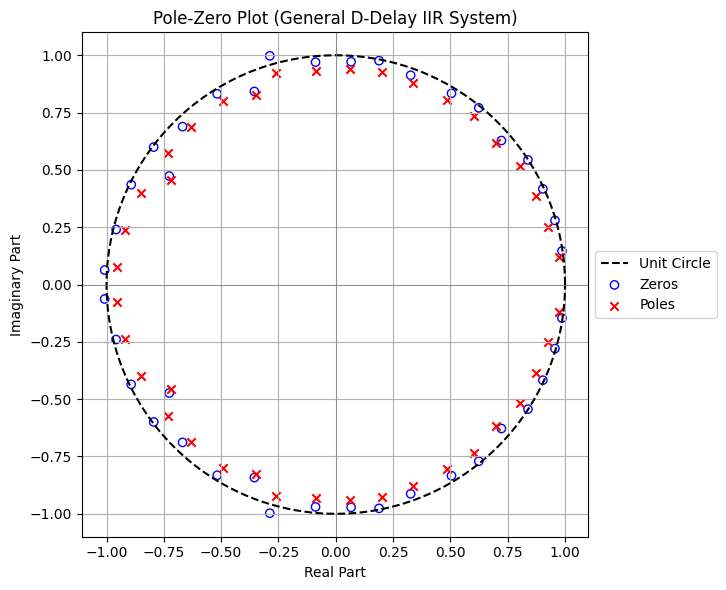

coeffs b: [0.13999979 0.02436692 0.03053855 0.00982547 0.05267766 0.05853954
 0.03619031 0.02302951 0.03268782 0.02526156 0.03219304 0.03772001
 0.04785016 0.04627581 0.03315814 0.05184765 0.03832731 0.01250886
 0.02430335 0.01080363 0.0264376  0.04185383 0.06063177 0.00378964
 0.01341936 0.01458646 0.04802758 0.02480622 0.02502551 0.03102924
 0.03380824 0.02875226 0.00821651 0.04701823 0.02691801 0.02188041
 0.0608726  0.00933241 0.04734338 0.00242402 0.0186407 ]
coeffs a: [1.         0.03944245 0.05019515 0.00975827 0.08627301 0.09527435
 0.05438678 0.03784942 0.05270653 0.04150033 0.05199225 0.06082443
 0.0753328  0.07603743 0.05396244 0.08413526 0.0623714  0.02068588
 0.03950548 0.01252811 0.04282311 0.06755235 0.09787213 0.00622922
 0.00835729 0.02002407 0.07636739 0.04065624 0.04118323 0.03907682
 0.05305997 0.0406048  0.01307367 0.0761942  0.03810879 0.0359944
 0.09994625 0.01548885 0.07751597 0.00406953 0.03059447]


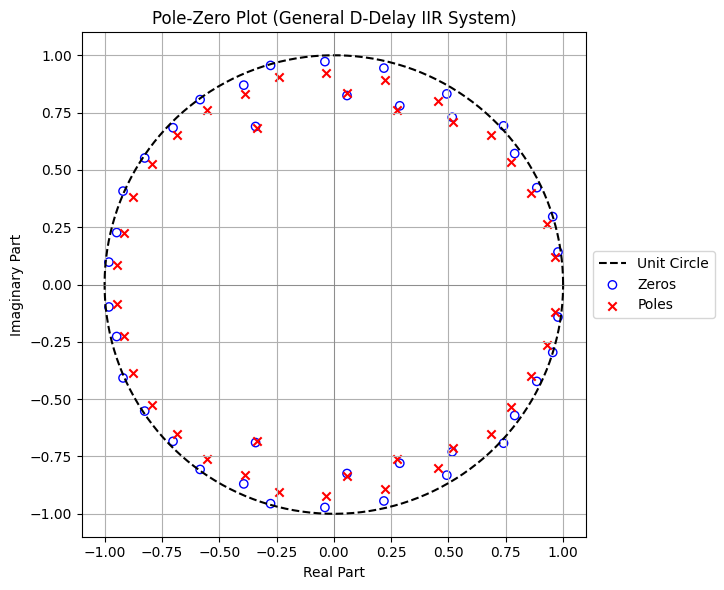

coeffs b: [0.13359144 0.02495825 0.01846136 0.03090592 0.01545457 0.06747343
 0.02980939 0.03497429 0.03041952 0.01874486 0.03840268 0.06126367
 0.0233575  0.03865764 0.00673839 0.03015994 0.04892163 0.065406
 0.02625484 0.00648758 0.06787899 0.06490508 0.00338368 0.04625261
 0.0192764  0.0272867  0.03751846 0.04862849 0.01586994 0.05557911
 0.04371804 0.00944871 0.03711892 0.04741578 0.06251717 0.03860262
 0.00577953 0.02443065 0.02681967 0.00346984 0.03712949]
coeffs a: [1.         0.03704661 0.01810163 0.04021451 0.02315306 0.09746798
 0.04447887 0.0524477  0.04484659 0.02776659 0.0572161  0.09258491
 0.01255398 0.05778975 0.00975722 0.04529287 0.07233191 0.09741431
 0.03862208 0.00976486 0.09961698 0.09733623 0.00510358 0.06958316
 0.02784659 0.04078721 0.05613365 0.07011392 0.01680591 0.08222063
 0.0645443  0.01220968 0.05356377 0.07124761 0.09303256 0.05807297
 0.00892155 0.03645517 0.03963102 0.00532514 0.05574825]


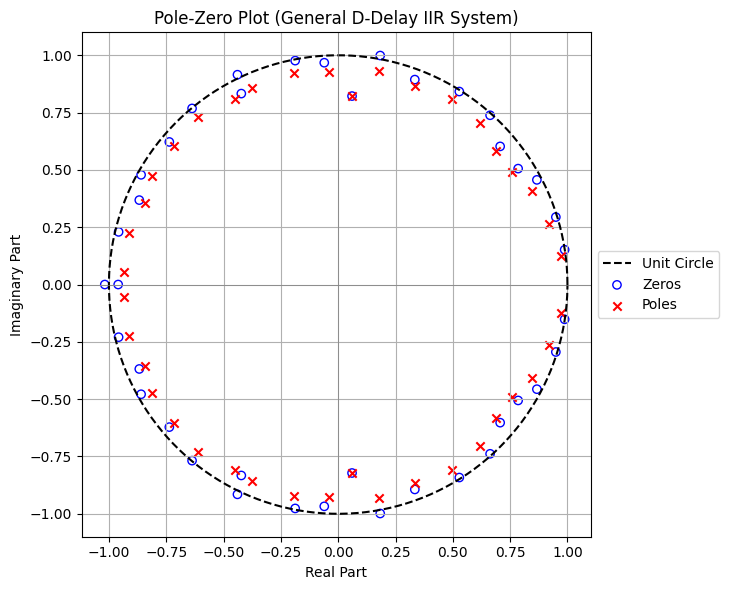

coeffs b: [0.15673256 0.03440759 0.03417607 0.00038897 0.02366081 0.02835794
 0.06148104 0.01654044 0.0288875  0.01813491 0.03967924 0.02319837
 0.01925517 0.01043072 0.01406569 0.01199103 0.05247326 0.03935011
 0.02958899 0.0597419  0.00241803 0.06138806 0.03520576 0.05604055
 0.02810893 0.03650687 0.01898943 0.00523325 0.03164852 0.04458602
 0.02119823 0.0511729  0.01870459 0.05434735 0.05125935 0.06142823
 0.02124848 0.04971223 0.02979017 0.06327166 0.02460699]
coeffs a: [1.0000000e+00 5.4008868e-02 5.3686678e-02 7.4700121e-04 3.7364125e-02
 4.4580448e-02 9.7335480e-02 1.3432122e-02 4.3012809e-02 2.7858591e-02
 6.2664799e-02 3.6576785e-02 3.0384684e-02 1.6513217e-02 2.2269940e-02
 1.8978750e-02 8.1598066e-02 6.0850348e-02 4.6242442e-02 9.3715303e-02
 4.3392777e-03 9.6916296e-02 5.5456307e-02 8.6415924e-02 4.3776132e-02
 5.2192118e-02 2.2658039e-02 9.0519193e-04 4.5207705e-02 7.0363760e-02
 2.7595593e-02 7.7753626e-02 2.9092385e-02 8.5112050e-02 8.1043720e-02
 9.3346611e-02 3.3549715

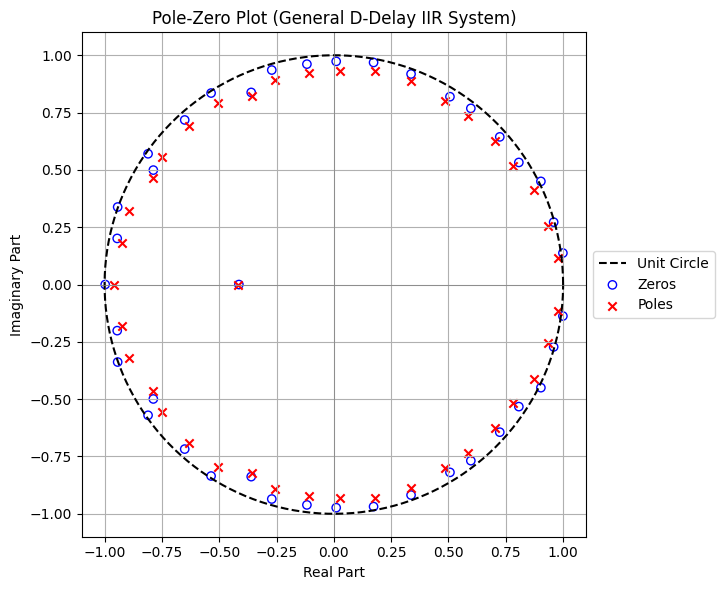

coeffs b: [0.19085273 0.01861305 0.03722742 0.01351185 0.00244609 0.01742417
 0.02351608 0.0626171  0.00735592 0.02281672 0.03227683 0.05690825
 0.06229295 0.01849333 0.05683041 0.02182899 0.02568388 0.05561212
 0.02396261 0.00220702 0.05731541 0.04646238 0.0520565  0.06110363
 0.04963408 0.02412902 0.02389514 0.00451652 0.05002796 0.02155761
 0.04211663 0.05946002 0.00695291 0.03691721 0.03580119 0.03437
 0.05005842 0.04158126 0.03373843 0.01001756 0.057043  ]
coeffs a: [1.         0.02908002 0.05800937 0.02122539 0.0038963  0.01713601
 0.01897911 0.09776206 0.01149468 0.03559726 0.05036695 0.08849297
 0.09626975 0.02887989 0.08662317 0.03381104 0.04009378 0.08679815
 0.03739587 0.00396531 0.08837807 0.07024037 0.07982739 0.09165712
 0.07704729 0.03757615 0.036244   0.00424072 0.07778911 0.03367399
 0.06575847 0.09286606 0.01068313 0.05346623 0.05475259 0.05296899
 0.07746728 0.06475061 0.04869144 0.01528099 0.08616932]


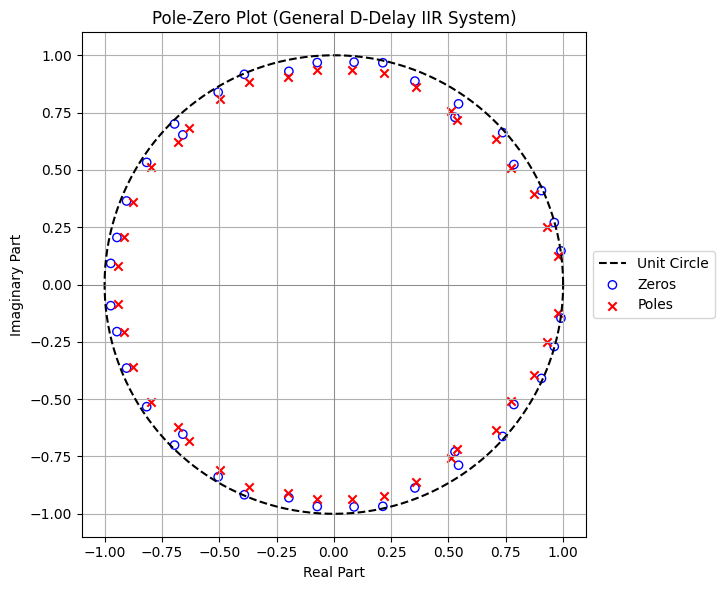

coeffs b: [0.18063176 0.02944953 0.04236644 0.0218969  0.0331618  0.03286755
 0.02172354 0.02434109 0.06218711 0.01802894 0.0329586  0.02099966
 0.03928285 0.0231516  0.02301841 0.04596973 0.05572723 0.00849293
 0.0244519  0.00656841 0.03521063 0.06440423 0.02085373 0.00840344
 0.03913222 0.05273458 0.03782757 0.04133818 0.00818448 0.03640566
 0.05541056 0.04805731 0.04951978 0.0165933  0.01184676 0.01664419
 0.04768747 0.02604408 0.05484316 0.05654126 0.06031291]
coeffs a: [1.         0.03723433 0.06530274 0.03082599 0.05041267 0.05052099
 0.03355894 0.03748138 0.09592668 0.02719778 0.05085027 0.03244
 0.06073827 0.01850154 0.03100163 0.06999002 0.08563962 0.01315066
 0.03757676 0.01015465 0.05381581 0.09851066 0.01219944 0.01072084
 0.06015411 0.07826193 0.05826949 0.06324031 0.01265354 0.05599772
 0.08564956 0.07228985 0.07630455 0.02189312 0.01835462 0.02566979
 0.07332268 0.04026302 0.08283173 0.08735486 0.09274385]


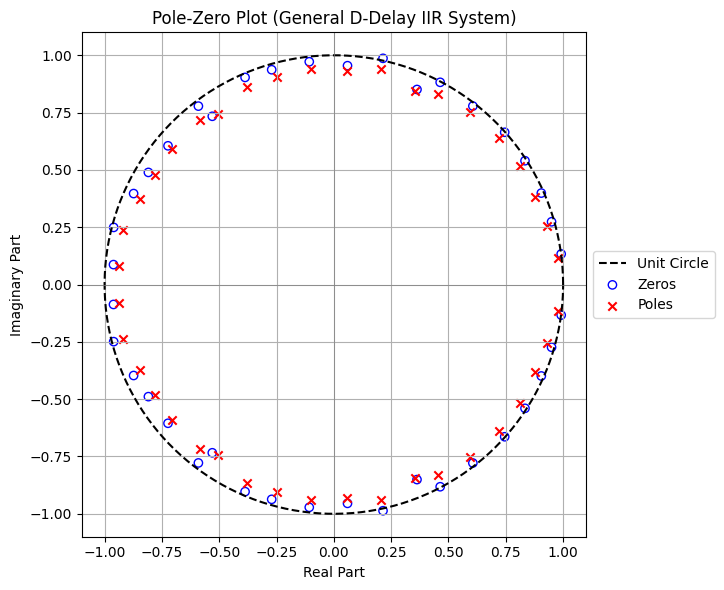

coeffs b: [0.1436948  0.01684567 0.04585393 0.02030627 0.00600032 0.042413
 0.02079683 0.01133318 0.05792277 0.02259158 0.06114784 0.02577982
 0.01056014 0.05471101 0.05034065 0.00556577 0.06225565 0.02747026
 0.02464538 0.03203766 0.01926122 0.04894729 0.00932071 0.00389731
 0.05236482 0.02484372 0.03209841 0.03198539 0.00484296 0.01867346
 0.02382414 0.03474292 0.04803719 0.04998642 0.05355566 0.04991655
 0.02603843 0.01191797 0.03832323 0.05272626 0.03911541]
coeffs a: [1.         0.02635998 0.07192266 0.03191203 0.00937601 0.06577616
 0.03266851 0.01791335 0.0908151  0.01722226 0.09219996 0.03478346
 0.01647897 0.08552285 0.07769985 0.00403053 0.09760417 0.0431807
 0.03863364 0.05033964 0.03000487 0.07597219 0.01180489 0.00238948
 0.08082793 0.03896889 0.04966774 0.0487113  0.00767306 0.02145503
 0.03054408 0.05471113 0.07479626 0.07853172 0.08400374 0.07845297
 0.03336677 0.01622695 0.05846955 0.08144795 0.05938481]


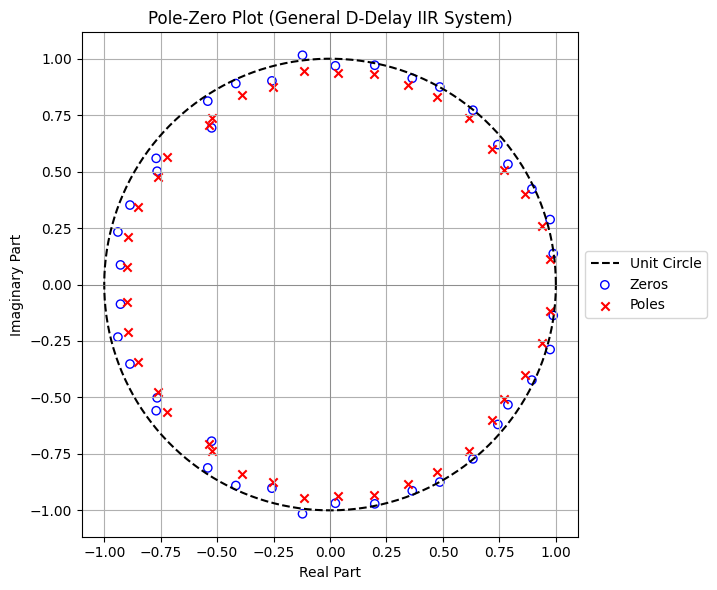

coeffs b: [0.10767694 0.04226056 0.01078459 0.05787577 0.03640874 0.02213629
 0.01853641 0.05778106 0.00753797 0.04573768 0.03359683 0.05478952
 0.03449139 0.00569649 0.02348972 0.03069465 0.00379568 0.0239301
 0.03521597 0.04323825 0.04115861 0.03387837 0.01837219 0.04024572
 0.05180522 0.02657155 0.00889808 0.04965575 0.03075982 0.02883187
 0.02690763 0.02080527 0.02136996 0.04460854 0.04037457 0.05617348
 0.01863268 0.00344171 0.02878972 0.03891633 0.04570097]
coeffs a: [1.         0.06986956 0.01747302 0.09511591 0.06017311 0.03651136
 0.03003958 0.09132897 0.0124624  0.07560536 0.05505897 0.08960334
 0.05634965 0.0045886  0.03889108 0.04997145 0.00618767 0.03910581
 0.05827913 0.07014848 0.06549098 0.0559803  0.02962983 0.06569778
 0.08556852 0.04389055 0.0147099  0.0819056  0.04655732 0.04725527
 0.04437571 0.03231842 0.02877336 0.07304775 0.0659488  0.0912832
 0.03074981 0.0019014  0.04728228 0.06165488 0.07485496]


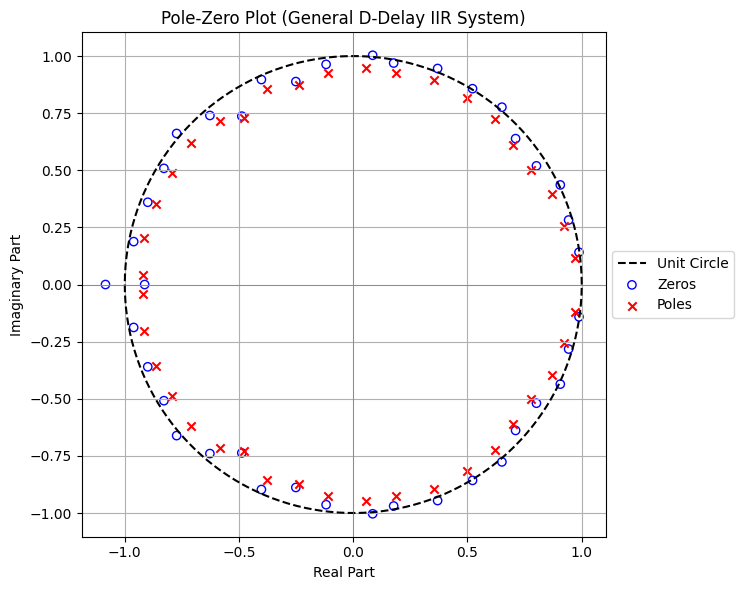

coeffs b: [0.16851503 0.00826612 0.04430786 0.04605237 0.0351215  0.06020543
 0.02592976 0.00249198 0.02792126 0.0158974  0.04088724 0.0578698
 0.06212089 0.03600845 0.00752894 0.01788155 0.02439998 0.03305071
 0.03140938 0.00544717 0.0484396  0.01063167 0.00339428 0.0589218
 0.04889908 0.01965212 0.01791848 0.0459924  0.04126047 0.02168483
 0.00134016 0.03308295 0.01116891 0.05777989 0.05101097 0.03354137
 0.00698801 0.05888299 0.05132803 0.06165078 0.03581306]
coeffs a: [1.         0.01308857 0.0695367  0.07270735 0.05446218 0.09464771
 0.04007784 0.00407525 0.04383873 0.02507507 0.06397096 0.09091116
 0.09737773 0.05572031 0.01201247 0.0282383  0.03810824 0.04365484
 0.04676529 0.00907388 0.07625629 0.01670595 0.00592203 0.09229922
 0.07721052 0.03093463 0.02811739 0.07239486 0.06439324 0.03395173
 0.00177929 0.05162469 0.01754506 0.08821269 0.08055854 0.05188517
 0.01109    0.09298127 0.08058204 0.09632634 0.05217925]


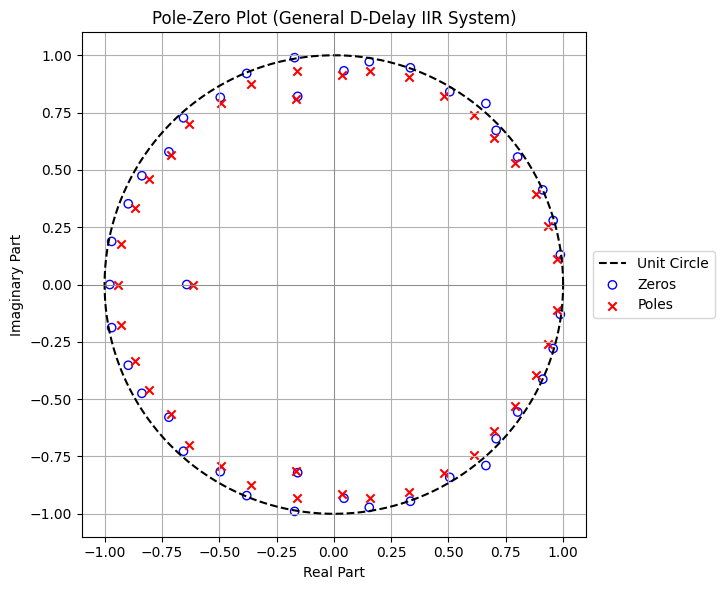

coeffs b: [0.15396993 0.05563838 0.06349646 0.05892599 0.05345714 0.04317495
 0.03255759 0.03318474 0.04348049 0.02851552 0.02766185 0.04333758
 0.06017351 0.01487537 0.06339703 0.03826848 0.02028218 0.02057347
 0.01335754 0.04894692 0.01695381 0.032531   0.06133991 0.03476806
 0.01463488 0.06015341 0.02534428 0.05435189 0.05674186 0.00411748
 0.00782491 0.0152466  0.03994238 0.02224576 0.02693382 0.00982835
 0.02978879 0.0485185  0.05836986 0.0418883  0.02449912]
coeffs a: [1.         0.08581101 0.09946903 0.08994272 0.0829906  0.06649312
 0.05090683 0.05202813 0.06790542 0.04225529 0.04303688 0.06772932
 0.0943675  0.02015531 0.09904839 0.05624448 0.00944067 0.01129174
 0.02096839 0.07672804 0.02640003 0.05099992 0.09312849 0.05407885
 0.01353137 0.09113275 0.03602966 0.08432784 0.0871125  0.00619014
 0.01248286 0.0233071  0.06228891 0.03489614 0.02962526 0.00900371
 0.04598972 0.07438911 0.09059411 0.06501374 0.03812565]


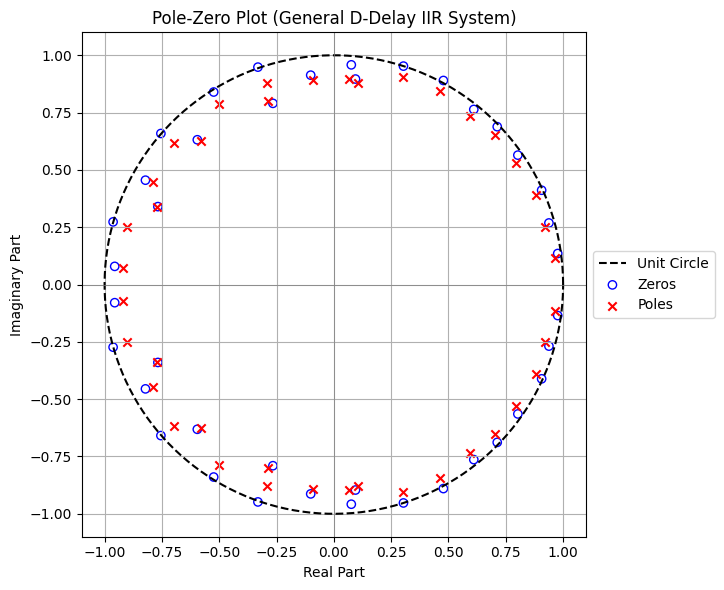

coeffs b: [0.1411702  0.03700592 0.03354514 0.01921726 0.01553765 0.04219043
 0.05867348 0.02774642 0.0161589  0.00117879 0.05229594 0.04341227
 0.02682355 0.00821848 0.05131526 0.00485706 0.02448949 0.02368464
 0.03137772 0.04187927 0.05124031 0.02095486 0.04327819 0.02227937
 0.05943621 0.0514204  0.02791943 0.02674561 0.05454368 0.00501814
 0.05028504 0.04914926 0.02558565 0.01762736 0.03181145 0.00592797
 0.05877658 0.05264188 0.00344235 0.04417799 0.04752418]
coeffs a: [1.         0.05948805 0.05314434 0.02703363 0.02436712 0.06749447
 0.09260824 0.04401907 0.02576555 0.00167625 0.08053105 0.06945281
 0.04311336 0.01311322 0.08089856 0.00781697 0.01219251 0.03347855
 0.04988603 0.06690847 0.08120226 0.03287915 0.06694962 0.03515733
 0.09495696 0.08174127 0.04490126 0.0429344  0.08599313 0.00804952
 0.08083512 0.07557973 0.04083746 0.02752302 0.05066575 0.00911506
 0.09138262 0.08300488 0.00548238 0.07072393 0.07495172]


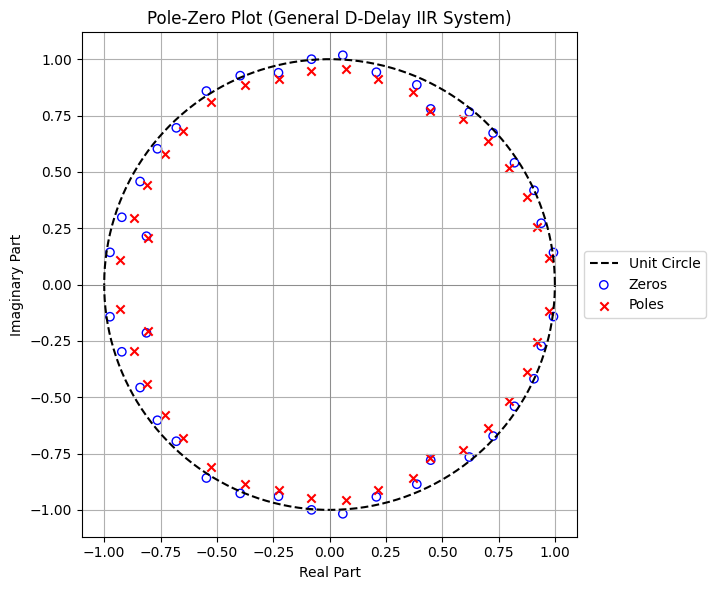

coeffs b: [1.7245659e-01 2.3334406e-02 2.7801333e-02 5.5962566e-02 5.6418873e-02
 2.1584012e-02 2.4116306e-02 2.5355281e-02 3.3981979e-02 5.3349044e-02
 5.5674199e-02 2.3991650e-02 1.6530475e-04 6.3391440e-02 2.3425691e-02
 2.2077242e-02 4.5174235e-03 3.6195733e-02 4.5989167e-02 1.3991502e-02
 2.7998778e-04 4.8449095e-02 1.6603570e-02 2.7513099e-03 5.0015371e-02
 1.4775062e-02 5.2022360e-02 3.9929435e-02 3.1552110e-02 1.1917898e-02
 5.3285688e-02 3.3448752e-02 3.0424036e-02 5.5725329e-02 3.2014254e-02
 4.8359077e-02 4.9321979e-02 2.5840048e-02 1.0421093e-02 6.1648224e-02
 2.2289010e-02]
coeffs a: [1.0000000e+00 3.6243644e-02 4.3109920e-02 8.5975789e-02 8.7267175e-02
 1.0361075e-03 3.4654226e-02 3.8525473e-02 5.2667893e-02 8.2872175e-02
 8.5418358e-02 3.6909260e-02 2.3937225e-04 9.7900830e-02 3.6018968e-02
 3.0690873e-02 6.8765404e-03 5.5784702e-02 6.9191732e-02 1.0947180e-02
 4.3046474e-04 7.5027838e-02 2.5723672e-02 4.2559388e-03 7.7048503e-02
 2.2724105e-02 7.8435086e-02 6.0973909e-0

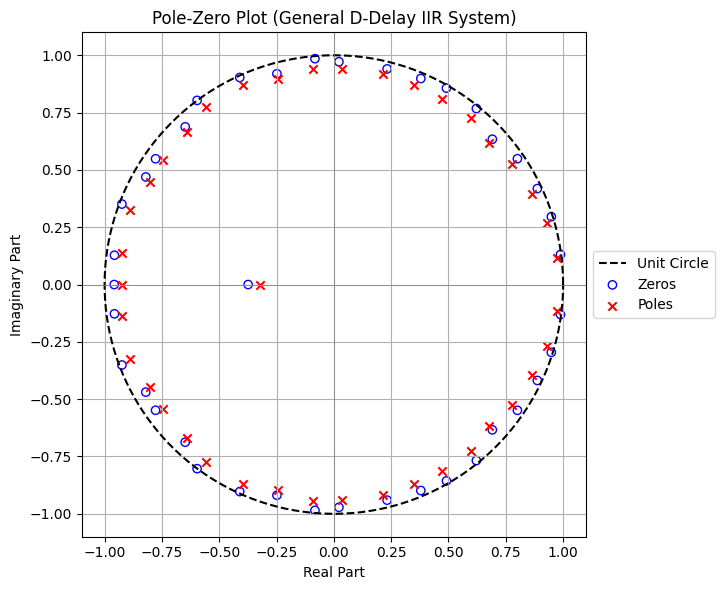

coeffs b: [0.12476429 0.04447251 0.01921034 0.02187358 0.00961248 0.02879728
 0.05759986 0.03714391 0.02969681 0.05253956 0.00279186 0.05742304
 0.04791446 0.01255092 0.00573415 0.04505974 0.05261578 0.04620305
 0.04188408 0.04574601 0.01748103 0.01305049 0.05566707 0.03274696
 0.02031271 0.05812239 0.03590317 0.0231686  0.03601505 0.04756376
 0.01138104 0.02555634 0.04336363 0.02313246 0.05164969 0.01599799
 0.04410825 0.01455797 0.03398979 0.04276944 0.05054489]
coeffs a: [1.0000000e+00 7.1025006e-02 2.2692908e-02 3.4843337e-02 7.2546485e-03
 4.3421458e-02 9.1994576e-02 5.7677258e-02 4.6734214e-02 8.0537356e-02
 4.6116472e-03 9.1890633e-02 7.5933374e-02 9.9986792e-04 9.1772797e-03
 7.2045900e-02 8.3126225e-02 7.1692087e-02 6.6971838e-02 7.3052049e-02
 2.7833020e-02 2.0865489e-02 8.9155488e-02 5.2156117e-02 3.2233812e-02
 9.1302358e-02 5.7430685e-02 3.6667265e-02 5.6294538e-02 7.3582627e-02
 1.8200172e-02 4.0144514e-02 6.9201268e-02 1.7160011e-02 8.1793956e-02
 2.5507092e-02 7.0637442

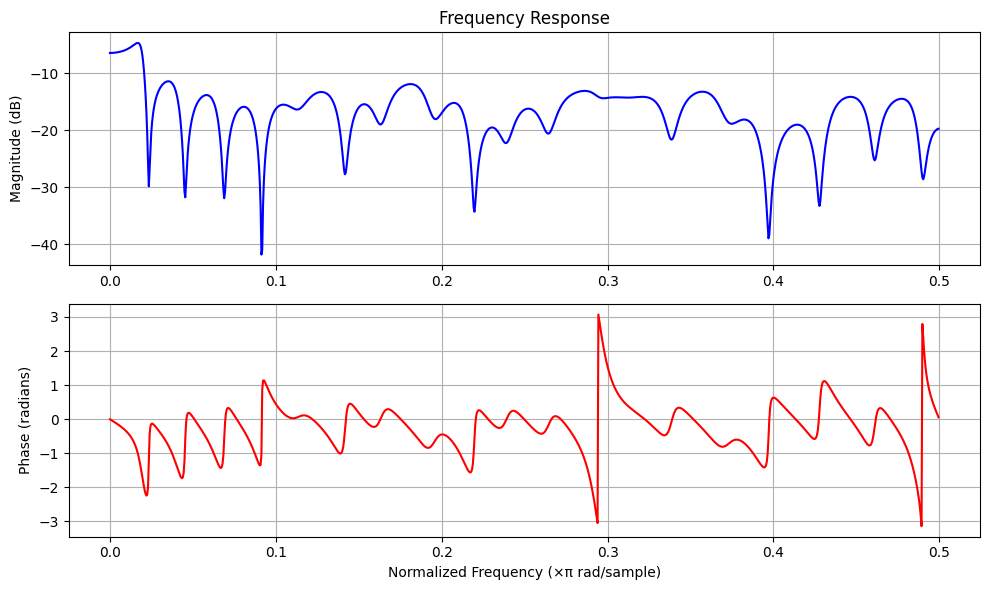

coeffs b: [0.13999979 0.02436692 0.03053855 0.00982547 0.05267766 0.05853954
 0.03619031 0.02302951 0.03268782 0.02526156 0.03219304 0.03772001
 0.04785016 0.04627581 0.03315814 0.05184765 0.03832731 0.01250886
 0.02430335 0.01080363 0.0264376  0.04185383 0.06063177 0.00378964
 0.01341936 0.01458646 0.04802758 0.02480622 0.02502551 0.03102924
 0.03380824 0.02875226 0.00821651 0.04701823 0.02691801 0.02188041
 0.0608726  0.00933241 0.04734338 0.00242402 0.0186407 ]
coeffs a: [1.         0.03944245 0.05019515 0.00975827 0.08627301 0.09527435
 0.05438678 0.03784942 0.05270653 0.04150033 0.05199225 0.06082443
 0.0753328  0.07603743 0.05396244 0.08413526 0.0623714  0.02068588
 0.03950548 0.01252811 0.04282311 0.06755235 0.09787213 0.00622922
 0.00835729 0.02002407 0.07636739 0.04065624 0.04118323 0.03907682
 0.05305997 0.0406048  0.01307367 0.0761942  0.03810879 0.0359944
 0.09994625 0.01548885 0.07751597 0.00406953 0.03059447]


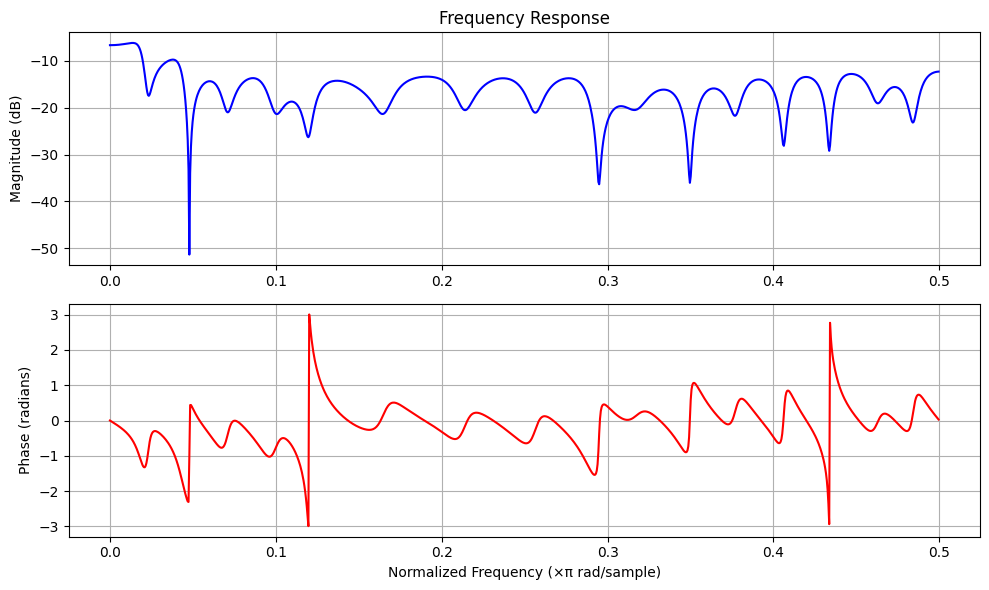

coeffs b: [0.13359144 0.02495825 0.01846136 0.03090592 0.01545457 0.06747343
 0.02980939 0.03497429 0.03041952 0.01874486 0.03840268 0.06126367
 0.0233575  0.03865764 0.00673839 0.03015994 0.04892163 0.065406
 0.02625484 0.00648758 0.06787899 0.06490508 0.00338368 0.04625261
 0.0192764  0.0272867  0.03751846 0.04862849 0.01586994 0.05557911
 0.04371804 0.00944871 0.03711892 0.04741578 0.06251717 0.03860262
 0.00577953 0.02443065 0.02681967 0.00346984 0.03712949]
coeffs a: [1.         0.03704661 0.01810163 0.04021451 0.02315306 0.09746798
 0.04447887 0.0524477  0.04484659 0.02776659 0.0572161  0.09258491
 0.01255398 0.05778975 0.00975722 0.04529287 0.07233191 0.09741431
 0.03862208 0.00976486 0.09961698 0.09733623 0.00510358 0.06958316
 0.02784659 0.04078721 0.05613365 0.07011392 0.01680591 0.08222063
 0.0645443  0.01220968 0.05356377 0.07124761 0.09303256 0.05807297
 0.00892155 0.03645517 0.03963102 0.00532514 0.05574825]


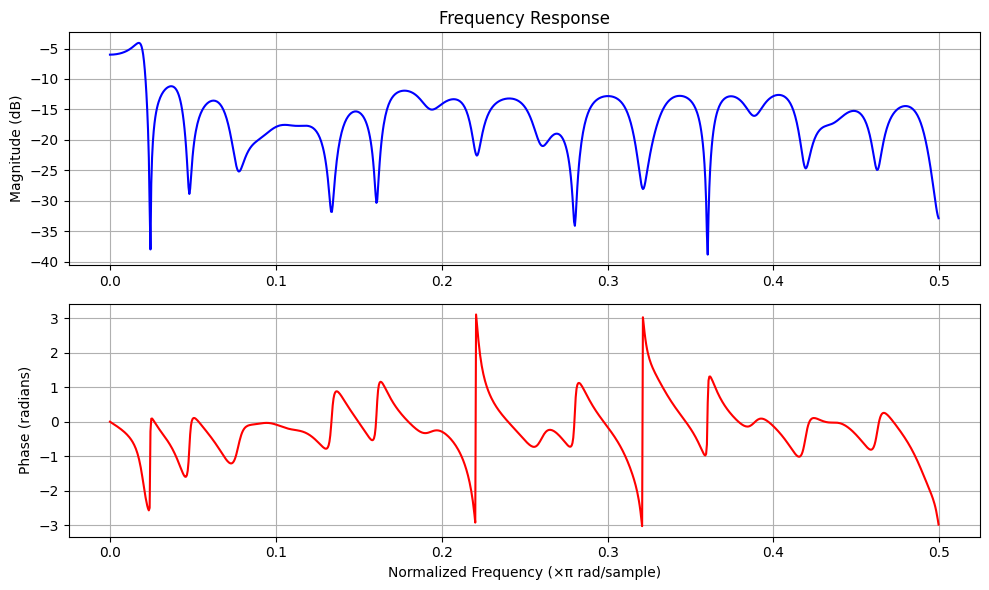

coeffs b: [0.15673256 0.03440759 0.03417607 0.00038897 0.02366081 0.02835794
 0.06148104 0.01654044 0.0288875  0.01813491 0.03967924 0.02319837
 0.01925517 0.01043072 0.01406569 0.01199103 0.05247326 0.03935011
 0.02958899 0.0597419  0.00241803 0.06138806 0.03520576 0.05604055
 0.02810893 0.03650687 0.01898943 0.00523325 0.03164852 0.04458602
 0.02119823 0.0511729  0.01870459 0.05434735 0.05125935 0.06142823
 0.02124848 0.04971223 0.02979017 0.06327166 0.02460699]
coeffs a: [1.0000000e+00 5.4008868e-02 5.3686678e-02 7.4700121e-04 3.7364125e-02
 4.4580448e-02 9.7335480e-02 1.3432122e-02 4.3012809e-02 2.7858591e-02
 6.2664799e-02 3.6576785e-02 3.0384684e-02 1.6513217e-02 2.2269940e-02
 1.8978750e-02 8.1598066e-02 6.0850348e-02 4.6242442e-02 9.3715303e-02
 4.3392777e-03 9.6916296e-02 5.5456307e-02 8.6415924e-02 4.3776132e-02
 5.2192118e-02 2.2658039e-02 9.0519193e-04 4.5207705e-02 7.0363760e-02
 2.7595593e-02 7.7753626e-02 2.9092385e-02 8.5112050e-02 8.1043720e-02
 9.3346611e-02 3.3549715

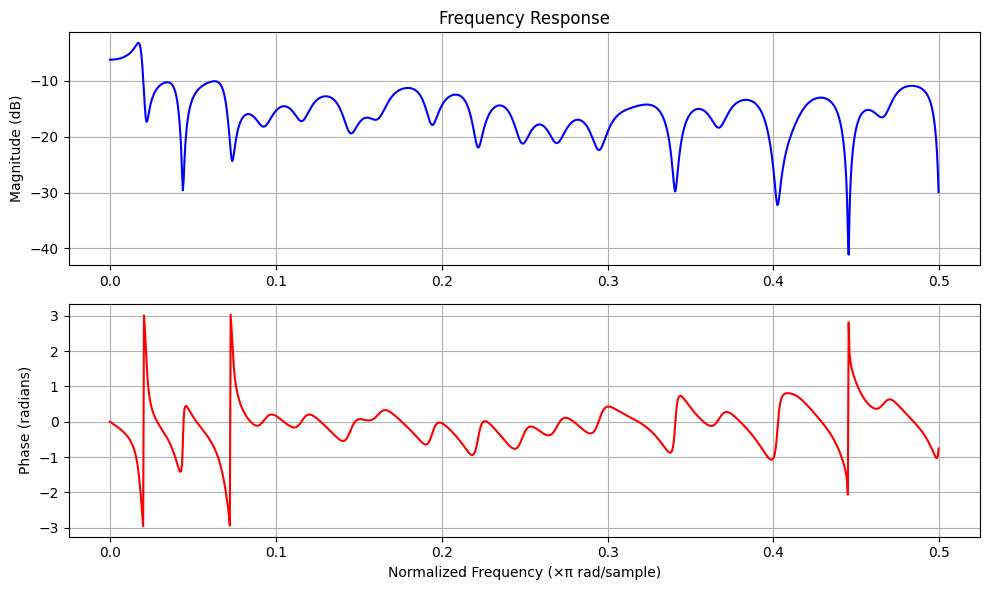

coeffs b: [0.19085273 0.01861305 0.03722742 0.01351185 0.00244609 0.01742417
 0.02351608 0.0626171  0.00735592 0.02281672 0.03227683 0.05690825
 0.06229295 0.01849333 0.05683041 0.02182899 0.02568388 0.05561212
 0.02396261 0.00220702 0.05731541 0.04646238 0.0520565  0.06110363
 0.04963408 0.02412902 0.02389514 0.00451652 0.05002796 0.02155761
 0.04211663 0.05946002 0.00695291 0.03691721 0.03580119 0.03437
 0.05005842 0.04158126 0.03373843 0.01001756 0.057043  ]
coeffs a: [1.         0.02908002 0.05800937 0.02122539 0.0038963  0.01713601
 0.01897911 0.09776206 0.01149468 0.03559726 0.05036695 0.08849297
 0.09626975 0.02887989 0.08662317 0.03381104 0.04009378 0.08679815
 0.03739587 0.00396531 0.08837807 0.07024037 0.07982739 0.09165712
 0.07704729 0.03757615 0.036244   0.00424072 0.07778911 0.03367399
 0.06575847 0.09286606 0.01068313 0.05346623 0.05475259 0.05296899
 0.07746728 0.06475061 0.04869144 0.01528099 0.08616932]


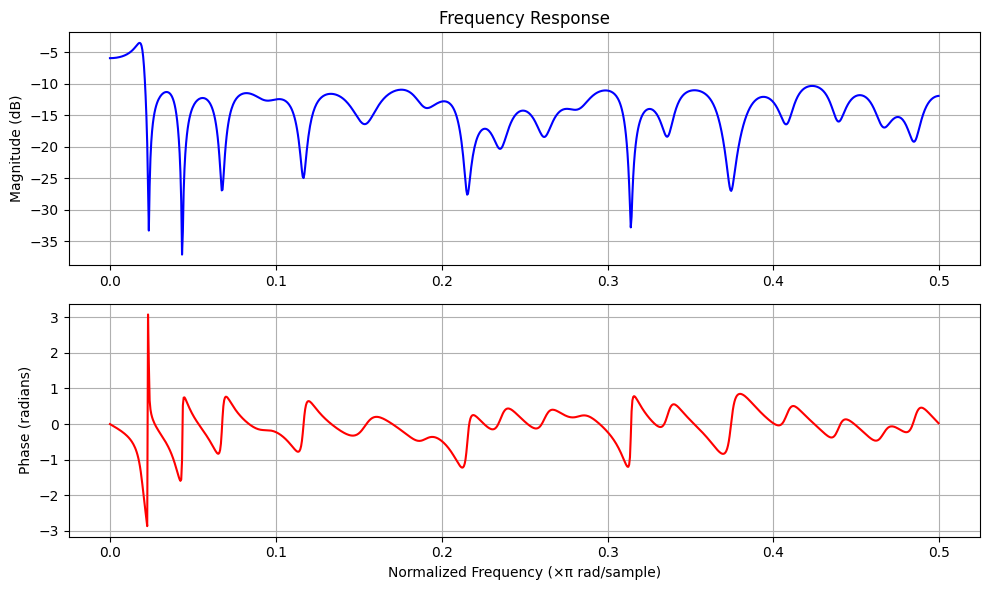

coeffs b: [0.18063176 0.02944953 0.04236644 0.0218969  0.0331618  0.03286755
 0.02172354 0.02434109 0.06218711 0.01802894 0.0329586  0.02099966
 0.03928285 0.0231516  0.02301841 0.04596973 0.05572723 0.00849293
 0.0244519  0.00656841 0.03521063 0.06440423 0.02085373 0.00840344
 0.03913222 0.05273458 0.03782757 0.04133818 0.00818448 0.03640566
 0.05541056 0.04805731 0.04951978 0.0165933  0.01184676 0.01664419
 0.04768747 0.02604408 0.05484316 0.05654126 0.06031291]
coeffs a: [1.         0.03723433 0.06530274 0.03082599 0.05041267 0.05052099
 0.03355894 0.03748138 0.09592668 0.02719778 0.05085027 0.03244
 0.06073827 0.01850154 0.03100163 0.06999002 0.08563962 0.01315066
 0.03757676 0.01015465 0.05381581 0.09851066 0.01219944 0.01072084
 0.06015411 0.07826193 0.05826949 0.06324031 0.01265354 0.05599772
 0.08564956 0.07228985 0.07630455 0.02189312 0.01835462 0.02566979
 0.07332268 0.04026302 0.08283173 0.08735486 0.09274385]


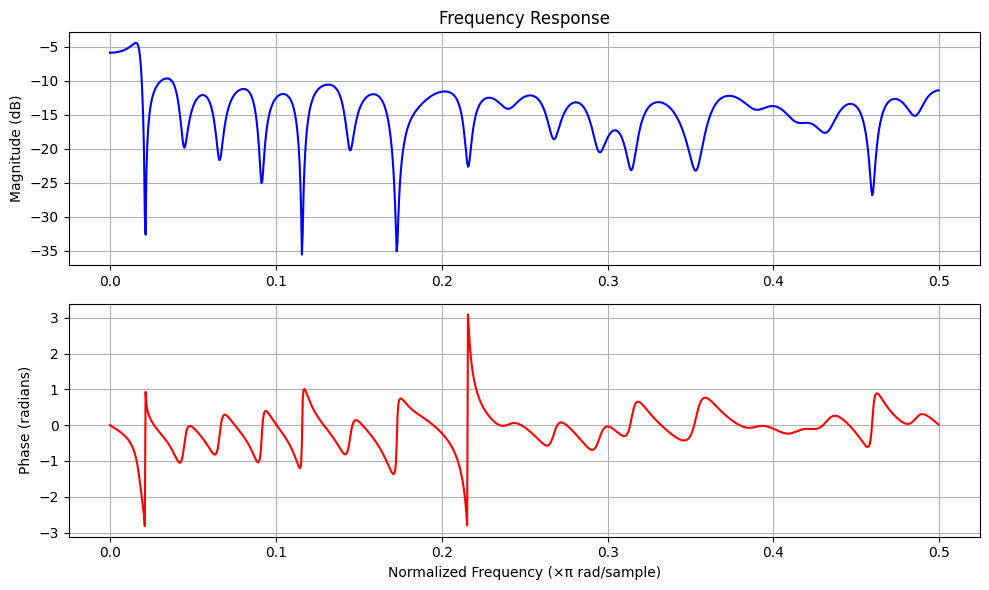

coeffs b: [0.1436948  0.01684567 0.04585393 0.02030627 0.00600032 0.042413
 0.02079683 0.01133318 0.05792277 0.02259158 0.06114784 0.02577982
 0.01056014 0.05471101 0.05034065 0.00556577 0.06225565 0.02747026
 0.02464538 0.03203766 0.01926122 0.04894729 0.00932071 0.00389731
 0.05236482 0.02484372 0.03209841 0.03198539 0.00484296 0.01867346
 0.02382414 0.03474292 0.04803719 0.04998642 0.05355566 0.04991655
 0.02603843 0.01191797 0.03832323 0.05272626 0.03911541]
coeffs a: [1.         0.02635998 0.07192266 0.03191203 0.00937601 0.06577616
 0.03266851 0.01791335 0.0908151  0.01722226 0.09219996 0.03478346
 0.01647897 0.08552285 0.07769985 0.00403053 0.09760417 0.0431807
 0.03863364 0.05033964 0.03000487 0.07597219 0.01180489 0.00238948
 0.08082793 0.03896889 0.04966774 0.0487113  0.00767306 0.02145503
 0.03054408 0.05471113 0.07479626 0.07853172 0.08400374 0.07845297
 0.03336677 0.01622695 0.05846955 0.08144795 0.05938481]


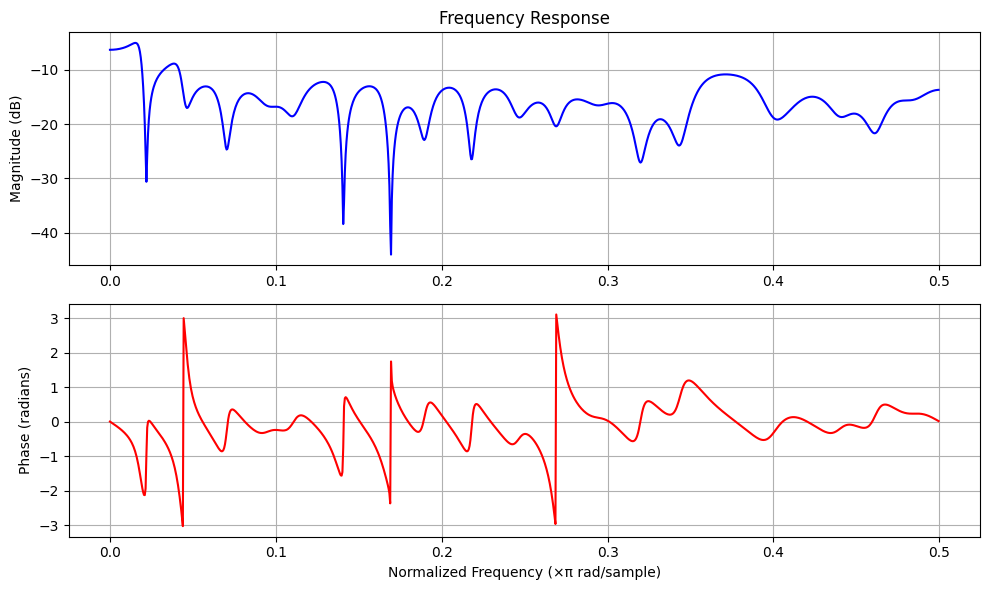

coeffs b: [0.10767694 0.04226056 0.01078459 0.05787577 0.03640874 0.02213629
 0.01853641 0.05778106 0.00753797 0.04573768 0.03359683 0.05478952
 0.03449139 0.00569649 0.02348972 0.03069465 0.00379568 0.0239301
 0.03521597 0.04323825 0.04115861 0.03387837 0.01837219 0.04024572
 0.05180522 0.02657155 0.00889808 0.04965575 0.03075982 0.02883187
 0.02690763 0.02080527 0.02136996 0.04460854 0.04037457 0.05617348
 0.01863268 0.00344171 0.02878972 0.03891633 0.04570097]
coeffs a: [1.         0.06986956 0.01747302 0.09511591 0.06017311 0.03651136
 0.03003958 0.09132897 0.0124624  0.07560536 0.05505897 0.08960334
 0.05634965 0.0045886  0.03889108 0.04997145 0.00618767 0.03910581
 0.05827913 0.07014848 0.06549098 0.0559803  0.02962983 0.06569778
 0.08556852 0.04389055 0.0147099  0.0819056  0.04655732 0.04725527
 0.04437571 0.03231842 0.02877336 0.07304775 0.0659488  0.0912832
 0.03074981 0.0019014  0.04728228 0.06165488 0.07485496]


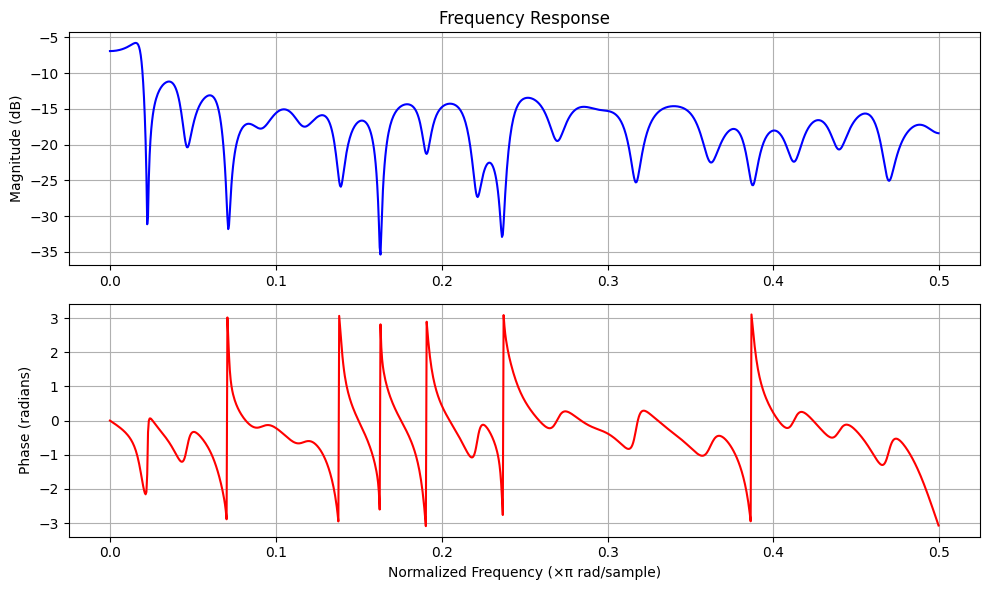

coeffs b: [0.16851503 0.00826612 0.04430786 0.04605237 0.0351215  0.06020543
 0.02592976 0.00249198 0.02792126 0.0158974  0.04088724 0.0578698
 0.06212089 0.03600845 0.00752894 0.01788155 0.02439998 0.03305071
 0.03140938 0.00544717 0.0484396  0.01063167 0.00339428 0.0589218
 0.04889908 0.01965212 0.01791848 0.0459924  0.04126047 0.02168483
 0.00134016 0.03308295 0.01116891 0.05777989 0.05101097 0.03354137
 0.00698801 0.05888299 0.05132803 0.06165078 0.03581306]
coeffs a: [1.         0.01308857 0.0695367  0.07270735 0.05446218 0.09464771
 0.04007784 0.00407525 0.04383873 0.02507507 0.06397096 0.09091116
 0.09737773 0.05572031 0.01201247 0.0282383  0.03810824 0.04365484
 0.04676529 0.00907388 0.07625629 0.01670595 0.00592203 0.09229922
 0.07721052 0.03093463 0.02811739 0.07239486 0.06439324 0.03395173
 0.00177929 0.05162469 0.01754506 0.08821269 0.08055854 0.05188517
 0.01109    0.09298127 0.08058204 0.09632634 0.05217925]


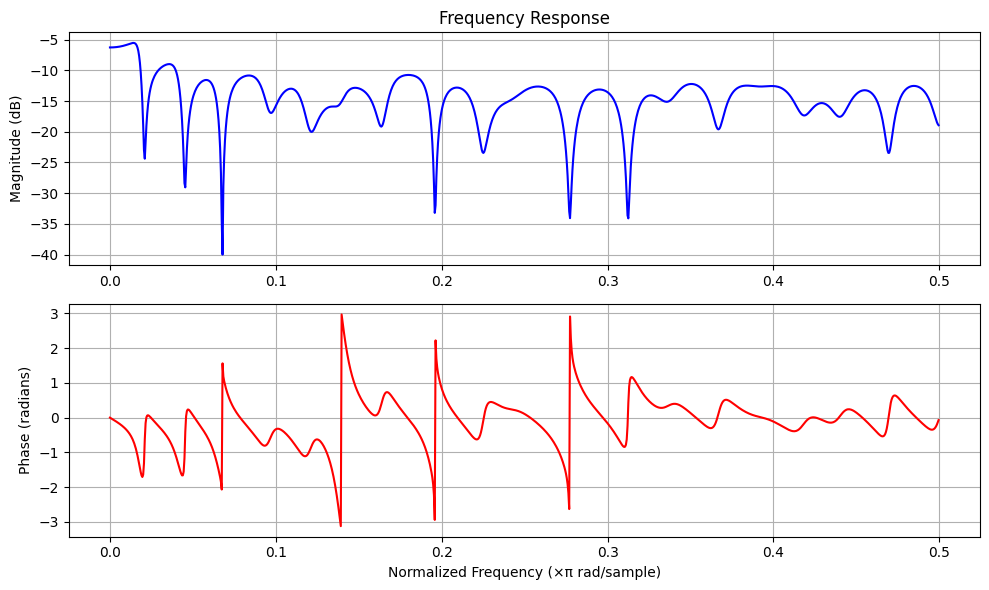

coeffs b: [0.15396993 0.05563838 0.06349646 0.05892599 0.05345714 0.04317495
 0.03255759 0.03318474 0.04348049 0.02851552 0.02766185 0.04333758
 0.06017351 0.01487537 0.06339703 0.03826848 0.02028218 0.02057347
 0.01335754 0.04894692 0.01695381 0.032531   0.06133991 0.03476806
 0.01463488 0.06015341 0.02534428 0.05435189 0.05674186 0.00411748
 0.00782491 0.0152466  0.03994238 0.02224576 0.02693382 0.00982835
 0.02978879 0.0485185  0.05836986 0.0418883  0.02449912]
coeffs a: [1.         0.08581101 0.09946903 0.08994272 0.0829906  0.06649312
 0.05090683 0.05202813 0.06790542 0.04225529 0.04303688 0.06772932
 0.0943675  0.02015531 0.09904839 0.05624448 0.00944067 0.01129174
 0.02096839 0.07672804 0.02640003 0.05099992 0.09312849 0.05407885
 0.01353137 0.09113275 0.03602966 0.08432784 0.0871125  0.00619014
 0.01248286 0.0233071  0.06228891 0.03489614 0.02962526 0.00900371
 0.04598972 0.07438911 0.09059411 0.06501374 0.03812565]


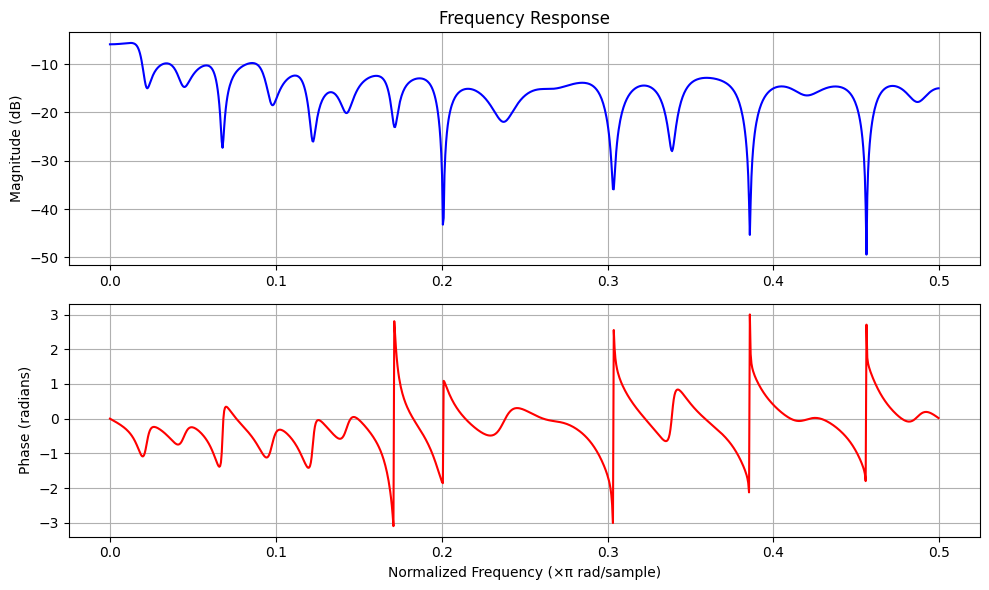

coeffs b: [0.1411702  0.03700592 0.03354514 0.01921726 0.01553765 0.04219043
 0.05867348 0.02774642 0.0161589  0.00117879 0.05229594 0.04341227
 0.02682355 0.00821848 0.05131526 0.00485706 0.02448949 0.02368464
 0.03137772 0.04187927 0.05124031 0.02095486 0.04327819 0.02227937
 0.05943621 0.0514204  0.02791943 0.02674561 0.05454368 0.00501814
 0.05028504 0.04914926 0.02558565 0.01762736 0.03181145 0.00592797
 0.05877658 0.05264188 0.00344235 0.04417799 0.04752418]
coeffs a: [1.         0.05948805 0.05314434 0.02703363 0.02436712 0.06749447
 0.09260824 0.04401907 0.02576555 0.00167625 0.08053105 0.06945281
 0.04311336 0.01311322 0.08089856 0.00781697 0.01219251 0.03347855
 0.04988603 0.06690847 0.08120226 0.03287915 0.06694962 0.03515733
 0.09495696 0.08174127 0.04490126 0.0429344  0.08599313 0.00804952
 0.08083512 0.07557973 0.04083746 0.02752302 0.05066575 0.00911506
 0.09138262 0.08300488 0.00548238 0.07072393 0.07495172]


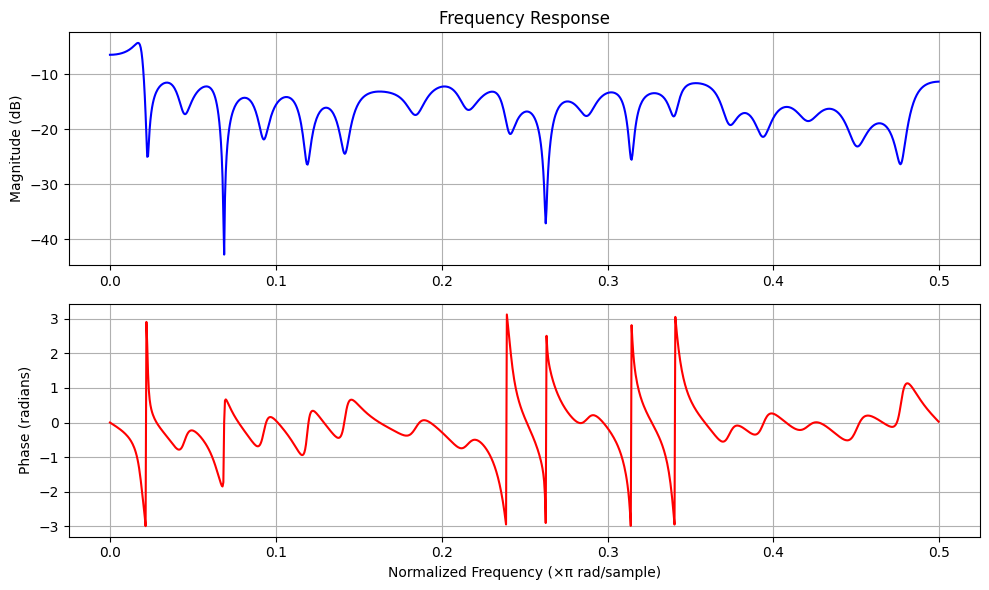

coeffs b: [1.7245659e-01 2.3334406e-02 2.7801333e-02 5.5962566e-02 5.6418873e-02
 2.1584012e-02 2.4116306e-02 2.5355281e-02 3.3981979e-02 5.3349044e-02
 5.5674199e-02 2.3991650e-02 1.6530475e-04 6.3391440e-02 2.3425691e-02
 2.2077242e-02 4.5174235e-03 3.6195733e-02 4.5989167e-02 1.3991502e-02
 2.7998778e-04 4.8449095e-02 1.6603570e-02 2.7513099e-03 5.0015371e-02
 1.4775062e-02 5.2022360e-02 3.9929435e-02 3.1552110e-02 1.1917898e-02
 5.3285688e-02 3.3448752e-02 3.0424036e-02 5.5725329e-02 3.2014254e-02
 4.8359077e-02 4.9321979e-02 2.5840048e-02 1.0421093e-02 6.1648224e-02
 2.2289010e-02]
coeffs a: [1.0000000e+00 3.6243644e-02 4.3109920e-02 8.5975789e-02 8.7267175e-02
 1.0361075e-03 3.4654226e-02 3.8525473e-02 5.2667893e-02 8.2872175e-02
 8.5418358e-02 3.6909260e-02 2.3937225e-04 9.7900830e-02 3.6018968e-02
 3.0690873e-02 6.8765404e-03 5.5784702e-02 6.9191732e-02 1.0947180e-02
 4.3046474e-04 7.5027838e-02 2.5723672e-02 4.2559388e-03 7.7048503e-02
 2.2724105e-02 7.8435086e-02 6.0973909e-0

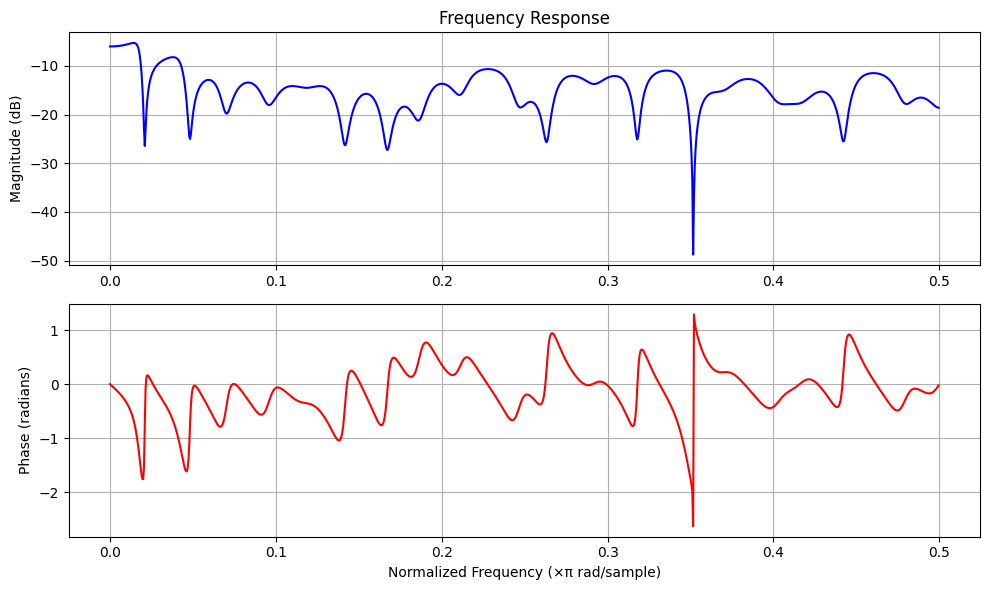

In [12]:
# for j in range(bs):
for ch in range(channels):
    # Plot for first batch and first channel
    b_example = layer.b[ch,:].numpy()
    a_example = layer.a[ch,:].numpy()
    print(f"coeffs b: {b_example}\ncoeffs a: {a_example}")
    plot_pole_zero(b_example, a_example)

# for j in range(bs):
for ch in range(channels):
    # Plot for first batch and first channel
    b_example = layer.b[ch,:].numpy()
    a_example = layer.a[ch,:].numpy()
    print(f"coeffs b: {b_example}\ncoeffs a: {a_example}")
    plot_frequency_response(b_example, a_example)


In [13]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Defining a model with IIR1D layer and Training

        Define an model with the IIR1D layer and check

In [14]:
# Dummy data
# batch_size, N, channels = 10, 5, 3
x_train = tf.random.normal((batch_size, N, channels))
y_dummy = tf.random.normal((batch_size, N, channels))
# y_dummy = tf.zeros_like(x_train)
x_train.shape, y_dummy.shape, x_train.dtype, y_dummy.dtype
# compile model
# model = Layer1D(D=Delays,max_steps=100)#N-1)
# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01))
# Build and compile model
# layer = Layer1D(D=N-1)


# def model(input_shape):
#     inputs = tf.keras.Input(shape=input_shape)  # shape: (batch, N, channels)
#     x = Layer1D(D=100)(inputs)        # shape: (batch, N, channels)
#     outputs = tf.keras.layers.Dense(channels)(x)  # project back to same shape
#     return tf.keras.Model(inputs=inputs, outputs=outputs)


# # # Fit model for 2 epochs
# # model.fit(x=x_train, y=y_dummy, epochs=2, batch_size=10)

(TensorShape([10, 128, 12]),
 TensorShape([10, 128, 12]),
 tf.float32,
 tf.float32)

In [15]:
def model(
    input_shape=(256, 1),
    Delays=Delays
    # loss = 'binary_crossentropy',
    # optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    # compile=True
    ):

    inputs = tf.keras.layers.Input(input_shape)
    q = IIRLayer1DIOsamesize(Delays, tolerance=1e-12, max_steps=100, local_lr=0.001,)(inputs)
    # q = IIRLayer1DIOsamesize(Delays, tolerance=1e-12, max_steps=100, local_lr=0.001,)(q)
    
    
    outputs = q  
    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    return model

    # if compile==True:
    #     # model = tf.keras.Model(inputs=[inputs], outputs=[x])
    #     # generator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)
    #     # model.compile(optimizer=generator_optimizer, loss=generator_loss)
       
    #     model.compile(optimizer=optimizer, loss=loss)
    #     return model
    #     #
    # else: 
    #     return model

D = 60
m = model(input_shape=(N, channels), Delays=D)  # (N=20, channels=16)
# m.compile(optimizer='adam', loss='mse')

# model = LayerModel(layer)
m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', jit_compile=False)  # Disable XLA for debugging)
m.summary()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 12)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ iir_layer1di_osamesize_2        │ (None, 128, 12)        │         1,452 │
│ (IIRLayer1DIOsamesize)          │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,452 (5.67 KB)

 Trainable params: 1,452 (5.67 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Run for 2 epochs
m.fit(x=x_train, y=y_dummy, epochs=10, batch_size=batch_size)

Epoch 1/10
Tensor("functional_1_1/iir_layer1di_osamesize_2_1/while/Placeholder:0", shape=(), dtype=int32), 

/data1/kishoretarafdar/miniforge3/envs/tf218/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_2']. Received: the structure of inputs=*
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 1.2057ype=int32)
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - loss: 1.2052
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step - loss: 1.1986
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - loss: 1.2042
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 1.2052
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - loss: 1.2017
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - loss: 1.2095
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step - loss: 1.1988
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - loss: 1.2010
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - loss: 1.2081


In [17]:
[_.shape for _ in m.layers[1].get_weights()]
# [_.shape for _ in m.layers[2].get_weights()]
# [_.shape for _ in m.layers[3].get_weights()]


[(12, 61), (12, 60)]

In [18]:
[_.shape for _ in m.weights]

[TensorShape([12, 61]), TensorShape([12, 60])]

In [19]:
m.weights[0].numpy()
m.weights[1].numpy().shape

(12, 60)

In [20]:
b = m.weights[0].numpy()
a = m.weights[1].numpy()
# b = m.weights[2].numpy()
# a = m.weights[3].numpy()

a0s = tf.ones((channels, 1))
a = tf.concat([a0s, a], axis=-1)  # shape: (channels, Delays+1)
a0s.shape, a.shape, b.shape

(TensorShape([12, 1]), TensorShape([12, 61]), (12, 61))

coeffs b: [-3.5774317e-02  1.6992227e-03  1.5856319e-03  1.2325892e-03
  9.1113383e-04 -5.2176020e-04  3.9710733e-04  1.4216991e-03
  1.8535963e-03 -1.0152168e-03  1.7343498e-03 -4.0015019e-04
 -5.8152061e-04  1.0885465e-03  8.1047835e-04  1.5054466e-03
  1.6578775e-03 -3.5581784e-04  1.4931331e-03 -5.5929949e-04
  1.5512914e-03  1.1522358e-03  1.6837162e-03  1.6166808e-03
 -7.6077040e-04  7.0115668e-04  8.0280786e-04  1.7765210e-03
 -9.0339151e-04  1.5594756e-03  1.8196249e-03  1.6380895e-03
  1.5306449e-03  1.2287190e-03  8.3424884e-04 -9.9226017e-04
  1.8727970e-03  1.6003252e-03  1.8957916e-03  1.3300793e-03
  6.8286411e-04  1.3748432e-03  1.5148069e-03 -2.2889976e-04
  7.7663921e-05 -4.2148633e-05  5.2906922e-04  1.2330995e-03
  3.0109333e-04 -1.5474646e-04  1.6212802e-03  1.6146707e-03
  4.8392662e-04 -6.9768401e-05  1.2163490e-03  9.7547646e-04
  1.2040220e-03  6.3994573e-04  2.8201309e-04  1.3760291e-07
  1.3001940e-03]
coeffs a: [1.         0.02336409 0.02744638 0.0381056  0.0

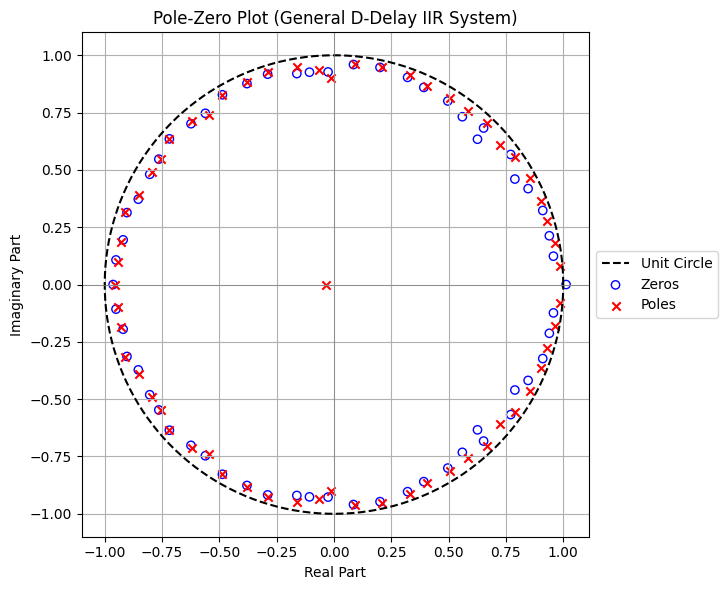

coeffs b: [0.03002924 0.00923231 0.00837193 0.00973512 0.00969918 0.00968094
 0.00862116 0.00748941 0.00958496 0.00976095 0.00780273 0.00578249
 0.01008459 0.00981359 0.00603783 0.0098213  0.00651787 0.00984601
 0.00953208 0.00911839 0.00937392 0.00837858 0.00966011 0.00614732
 0.00848581 0.00963787 0.00985482 0.00981157 0.00921311 0.00888416
 0.00884588 0.0094561  0.00610254 0.00828646 0.00794993 0.00949926
 0.00894232 0.00832474 0.00910904 0.00837005 0.0081244  0.00869986
 0.00549542 0.00760512 0.00736462 0.0096194  0.00987508 0.0085482
 0.00060689 0.00930785 0.00981531 0.00823732 0.00865734 0.00817039
 0.00478239 0.00727626 0.0079634  0.00940103 0.01001415 0.00928445
 0.00933683]
coeffs a: [1.0000000e+00 6.4071991e-02 3.5418738e-02 8.1901073e-02 8.1826024e-02
 8.2030788e-02 4.4576477e-02 1.9040752e-02 7.7697180e-02 8.5562646e-02
 2.3109591e-02 6.4228773e-03 9.5957898e-02 8.6055651e-02 7.6011657e-03
 8.5821711e-02 1.0047734e-02 8.7826826e-02 7.5043403e-02 6.0513962e-02
 6.8841159e-02

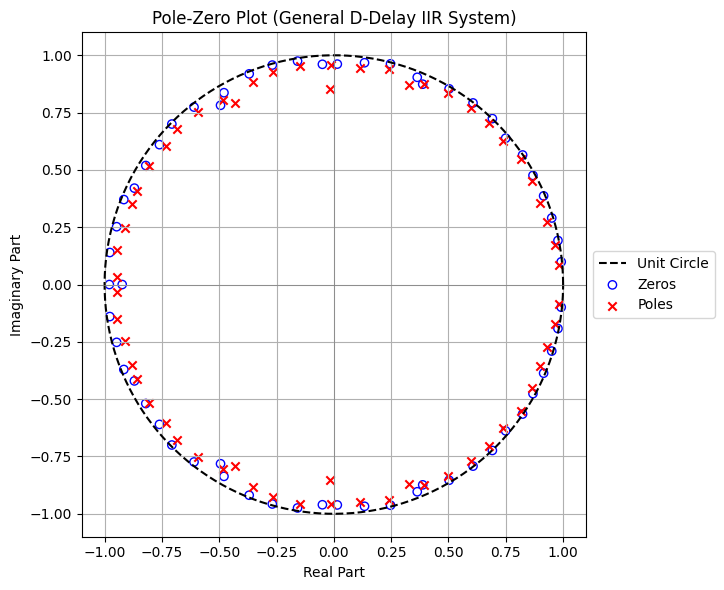

coeffs b: [-0.02621378 -0.00980865 -0.01003724 -0.00352455 -0.00923118 -0.00980494
 -0.01076492 -0.01065683 -0.00936588 -0.00936826 -0.0089134  -0.00951946
 -0.00979218 -0.00897151 -0.00814394 -0.0083782  -0.01067942 -0.01068221
 -0.00980145 -0.00959972 -0.0076599  -0.01093178 -0.00940058 -0.01021733
 -0.00989705 -0.01003847 -0.00966311 -0.01061385 -0.00208424 -0.01079649
 -0.00978077 -0.01033568 -0.0097593  -0.00677282 -0.0098952  -0.01072682
 -0.01097499 -0.0101142  -0.00993012 -0.01005505 -0.00919383 -0.0098457
 -0.01078414 -0.01021378 -0.00772477 -0.0038697  -0.01007603 -0.009606
 -0.0101527  -0.0103886  -0.0073317  -0.01089012 -0.0097229  -0.01015437
 -0.00383852 -0.00856118 -0.01028838 -0.00985818 -0.01028865 -0.01001522
 -0.01005345]
coeffs a: [1.0000000e+00 4.0755462e-02 5.1287580e-02 7.8358653e-04 2.1140873e-02
 4.4159867e-02 8.7057590e-02 8.6369097e-02 2.6629901e-02 2.7430667e-02
 1.6050994e-02 3.2039370e-02 4.3079305e-02 1.7351424e-02 7.7057839e-03
 9.5625399e-03 8.6121872e-

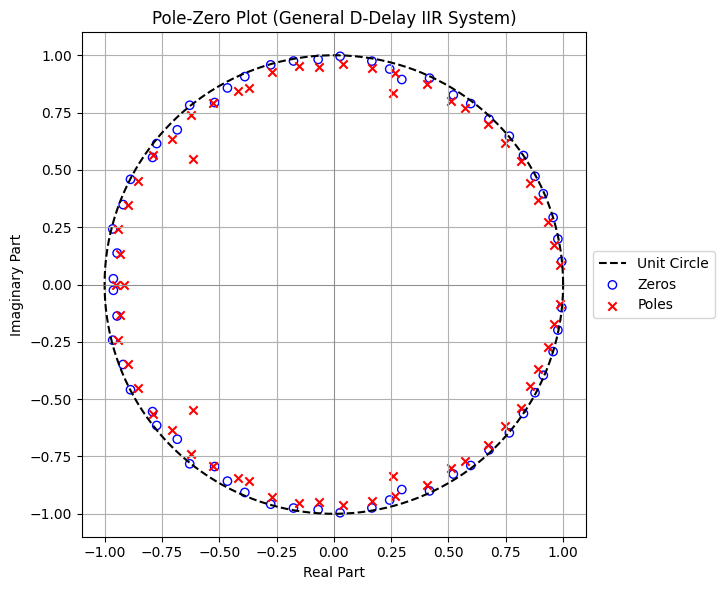

coeffs b: [-0.01966461 -0.00802457 -0.00493452 -0.00844422 -0.00745484 -0.00850153
 -0.00815751 -0.00501409 -0.00820338 -0.0077686  -0.00771541 -0.0066169
 -0.00455819 -0.00813896 -0.00809593 -0.00853477 -0.00820933 -0.00836235
 -0.00607656 -0.00742094 -0.00597079 -0.00735576 -0.00764588 -0.00850426
 -0.00726238 -0.00835375 -0.00747703 -0.00767244 -0.00835847 -0.00795467
 -0.00848711 -0.00746272 -0.0075445  -0.00755442 -0.00589566 -0.00746995
 -0.00762294 -0.00834822 -0.00779825 -0.00786536 -0.00460845 -0.00774072
 -0.00790131 -0.00705842 -0.00645302 -0.00523903 -0.00833511 -0.00691848
 -0.00790506 -0.00756466 -0.00795544 -0.00603045 -0.00297222 -0.00820782
 -0.00727819 -0.00819768 -0.00773253 -0.00748427 -0.0074832  -0.00798244
 -0.00741623]
coeffs a: [1.         0.06550985 0.00479937 0.0946631  0.03429356 0.09347724
 0.07533758 0.00507588 0.07825545 0.0506704  0.04922092 0.01514063
 0.00399563 0.07400196 0.06767926 0.09532042 0.07577632 0.08935203
 0.00973091 0.03376338 0.00940141 0.

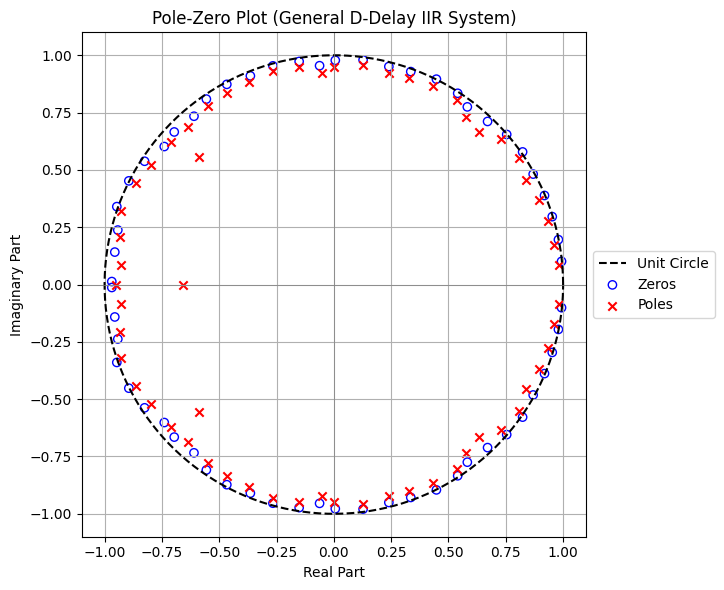

coeffs b: [ 0.00158041 -0.00287692 -0.00293823 -0.00296739 -0.00143552 -0.00288314
 -0.002914   -0.00296007 -0.00297446 -0.00286245 -0.00295869 -0.00288673
 -0.00288146 -0.00272496 -0.00274561 -0.0028644  -0.00291575 -0.00294449
 -0.00292508 -0.00284893 -0.00285121 -0.00297525 -0.00293681 -0.00279827
 -0.00292475 -0.00206765 -0.00296658 -0.00289463 -0.00294397 -0.00280781
 -0.00290265 -0.0028463  -0.00294925 -0.00293313 -0.00251811 -0.00297169
 -0.00281678 -0.00298165 -0.00296824 -0.00295259 -0.00294757 -0.00292222
 -0.00289151 -0.00276928 -0.0029285  -0.00281621 -0.00297675 -0.00210639
 -0.00283919 -0.00286425 -0.00298422 -0.00293256 -0.00296486 -0.00287807
 -0.00297721 -0.00296077 -0.00292824 -0.00289288 -0.0028763  -0.00290245
 -0.00290876]
coeffs a: [1.         0.08676535 0.07089912 0.05981419 0.0030606  0.09488881
 0.07347538 0.06599069 0.05812149 0.08988234 0.03687987 0.08241206
 0.09395847 0.01791962 0.01891505 0.09945367 0.08131857 0.0426976
 0.07526898 0.09532186 0.09928282 0.

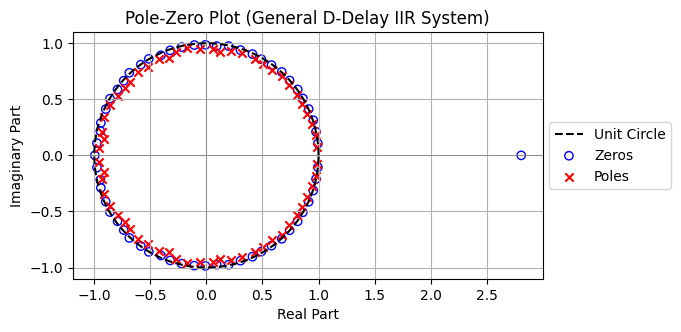

coeffs b: [ 0.0416035  -0.00619846 -0.0058397  -0.00677795 -0.00494645 -0.00695733
 -0.00506436 -0.00543168 -0.00590861 -0.00382122 -0.00685198 -0.00698498
 -0.00435861 -0.00613914 -0.00668831 -0.00682652 -0.00641947 -0.0067731
 -0.00642886 -0.00549533 -0.00500472 -0.0060013  -0.00684999 -0.00597622
 -0.0045133  -0.00416732 -0.00543085 -0.00398148 -0.00680794 -0.00708296
 -0.00661372 -0.00572018 -0.00560828 -0.00539462 -0.00626515 -0.00531478
 -0.00681004 -0.00467995 -0.00692425 -0.00474444 -0.00361914 -0.00557184
 -0.00691859 -0.00711531 -0.00492402 -0.00649766 -0.00584237 -0.00492227
 -0.00453833 -0.00355562 -0.00613782 -0.00713848 -0.0063627  -0.0055375
 -0.00462465 -0.00480867 -0.0058994  -0.00714534 -0.00347752 -0.00517042
 -0.00534665]
coeffs a: [1.         0.0429193  0.00307132 0.03035893 0.06908851 0.02351257
 0.0671037  0.05859257 0.04819851 0.09346779 0.02631698 0.02212888
 0.0819132  0.04322689 0.03209066 0.02700045 0.03836821 0.02848674
 0.03857354 0.05901879 0.06977862 0.0

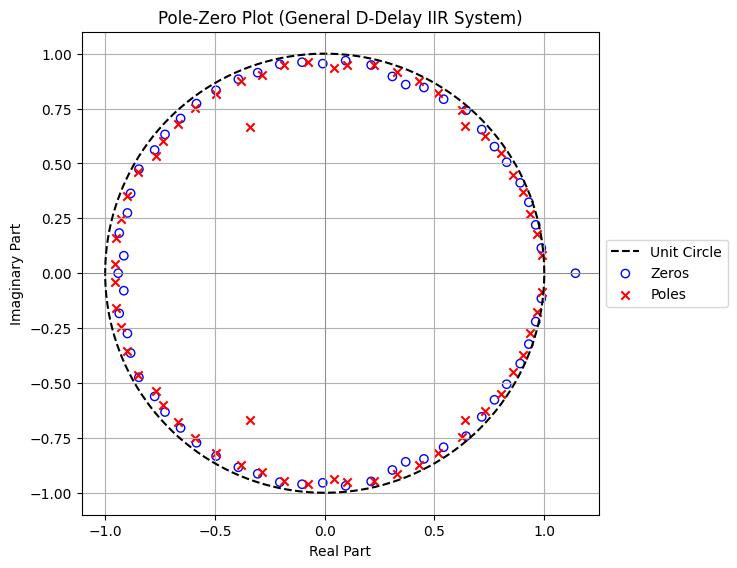

coeffs b: [-0.01363024 -0.00565644 -0.00437176 -0.00464845 -0.00391399 -0.0057941
 -0.00437183 -0.0053722  -0.00226412 -0.00516668 -0.00525908 -0.00335884
 -0.00534747 -0.0056208  -0.0053023  -0.00043358 -0.00536001 -0.00587187
 -0.0057514  -0.00582387 -0.00526128 -0.00469037 -0.00301589 -0.00538748
 -0.00338489 -0.0041031  -0.00478149 -0.00206    -0.00526077 -0.00524985
 -0.0046688  -0.00551558 -0.00573404 -0.00032761 -0.00542471 -0.00510478
 -0.0054663  -0.00534578 -0.00549287 -0.00524299 -0.00155499 -0.00566252
 -0.00495563 -0.00416708 -0.00559205 -0.00579608 -0.00409349 -0.00461629
 -0.00571814 -0.00533341 -0.00426589 -0.00580066 -0.00532963 -0.00580846
 -0.0057316  -0.00523863 -0.00567527 -0.00546081 -0.00511271 -0.00496888
 -0.00573981]
coeffs a: [1.00000000e+00 8.20023343e-02 1.57118198e-02 2.21185330e-02
 9.61929560e-03 9.83811617e-02 1.60451420e-02 5.60241453e-02
 2.63754139e-03 4.18462418e-02 5.21894097e-02 5.97139588e-03
 5.44669405e-02 7.71925449e-02 5.08965850e-02 3.100514

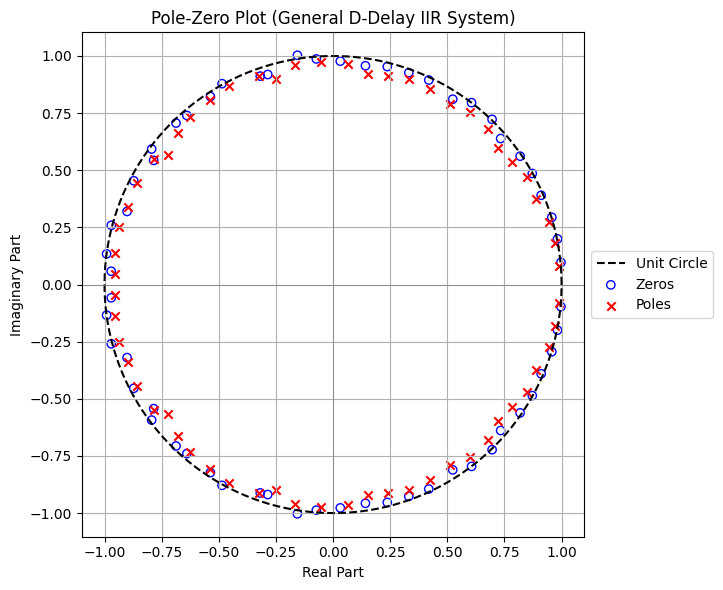

coeffs b: [0.03696042 0.00975364 0.00923428 0.01060986 0.01110052 0.01204485
 0.01114406 0.00907455 0.00981355 0.00847762 0.01074223 0.01098598
 0.00990926 0.01011236 0.00940356 0.00450705 0.01184659 0.01217472
 0.01139798 0.00356232 0.01232618 0.01196376 0.01121907 0.01044455
 0.00947515 0.0117191  0.00975413 0.01099047 0.01189128 0.0120902
 0.01086808 0.00887657 0.01005991 0.01054556 0.01021629 0.01004332
 0.01071475 0.01163129 0.01163549 0.01130512 0.01210724 0.00967517
 0.0094918  0.01196548 0.01201637 0.0111525  0.01183794 0.01013506
 0.00713277 0.01018223 0.0113413  0.01064064 0.01212775 0.00986398
 0.01136484 0.0104708  0.00886055 0.01000649 0.01074566 0.00922015
 0.01147639]
coeffs a: [1.0000000e+00 2.0774221e-02 1.3141406e-02 4.3101944e-02 6.0395766e-02
 9.2652991e-02 6.3185252e-02 1.1230267e-02 2.3209108e-02 6.6206097e-03
 4.6593368e-02 5.7321131e-02 2.4070919e-02 3.0619955e-02 1.5256166e-02
 9.4918016e-04 8.7518387e-02 9.5055178e-02 6.9960773e-02 6.2750577e-04
 9.9836230e-02

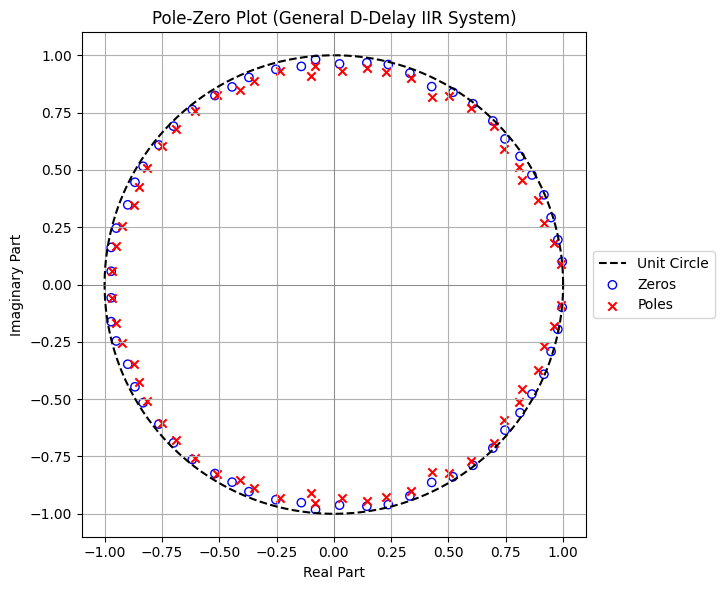

coeffs b: [-0.01046593 -0.00896626 -0.00901191 -0.00917635 -0.00870567 -0.00882195
 -0.00871195 -0.00873602 -0.00852109 -0.00899045 -0.00836194 -0.00769757
 -0.009078   -0.00645455 -0.00906937 -0.00916837 -0.00799515 -0.00883388
 -0.0082989  -0.00906819 -0.00876994 -0.00910283 -0.00880913 -0.00877786
 -0.00917499 -0.00869223 -0.00890532 -0.00885234 -0.00899781 -0.00910237
 -0.00915246 -0.0082336  -0.00902825 -0.00908124 -0.00786275 -0.0091127
 -0.00915452 -0.00632619 -0.00859097 -0.00795371 -0.00576793 -0.00310783
 -0.0091854  -0.00894151 -0.00919281 -0.00913997 -0.00880733 -0.00858419
 -0.00893304 -0.00891623 -0.00909762 -0.00915467 -0.00851901 -0.00873884
 -0.00902384 -0.00860395 -0.00876002 -0.00872689 -0.008679   -0.00895438
 -0.00808279]
coeffs a: [1.         0.05600346 0.06417622 0.09658022 0.03382286 0.038213
 0.0335641  0.03263041 0.02219788 0.06725375 0.02055912 0.00994519
 0.0894989  0.00464406 0.08881076 0.09746265 0.01314007 0.04035083
 0.01895549 0.08668496 0.0356195  0.09

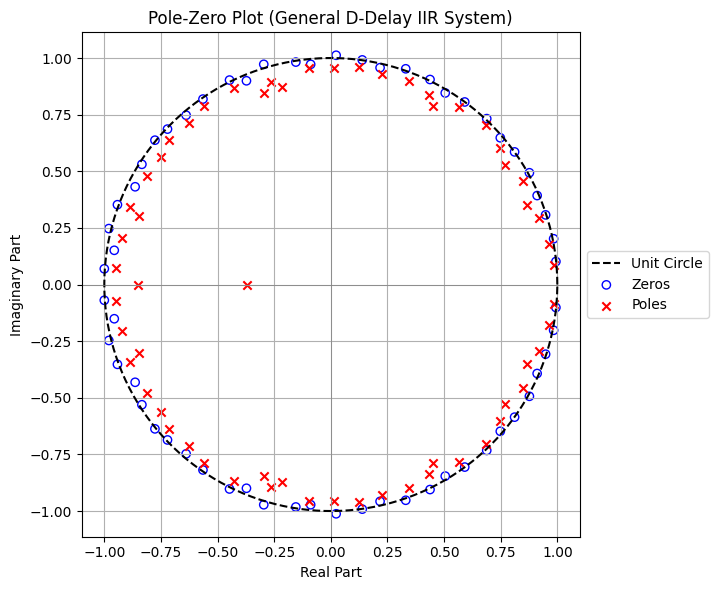

coeffs b: [-0.00288169 -0.00734651 -0.00614186 -0.00737536 -0.00734388 -0.00732622
 -0.00741464 -0.00729907 -0.00723267 -0.00727614 -0.00736335 -0.00731926
 -0.00733714 -0.0073739  -0.00697336 -0.00742062 -0.0069557  -0.00741739
 -0.00707913 -0.00738445 -0.00555044 -0.00738224 -0.00737246 -0.00734848
 -0.00746663 -0.00741954 -0.00728964 -0.00688103 -0.00739535 -0.00746789
 -0.00741288 -0.00736916 -0.00737586 -0.00736498 -0.00738341 -0.00741821
 -0.00733925 -0.00747069 -0.00737254 -0.0074651  -0.00747215 -0.00724285
 -0.00741775 -0.00737481 -0.00741637 -0.00742661 -0.00643824 -0.0072395
 -0.00737272 -0.00714976 -0.00730751 -0.00738071 -0.00566306 -0.0073792
 -0.00741924 -0.00734435 -0.00735778 -0.00742907 -0.00734732 -0.00738681
 -0.00747242]
coeffs a: [1.         0.03368847 0.00687611 0.04012007 0.028061   0.09575403
 0.04723924 0.09425193 0.02267048 0.0237604  0.07063488 0.09155922
 0.09251823 0.09302162 0.01500322 0.0871798  0.01427619 0.07715044
 0.0175161  0.06904642 0.00475332 0.0

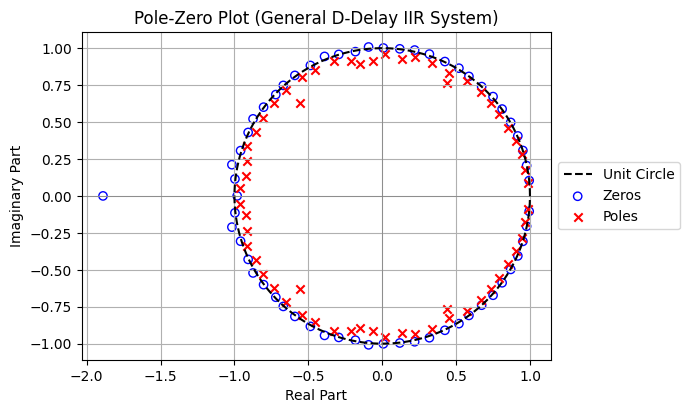

coeffs b: [-1.67850461e-02  3.23457643e-04  1.49707426e-04 -9.46621876e-04
  1.16303330e-04  1.23967737e-04 -8.48955533e-04  1.60889496e-04
 -6.45174994e-04  2.38785142e-04 -9.94671718e-05 -1.05426367e-03
  8.20216956e-05  1.85225566e-04 -9.15382348e-04  2.29292025e-04
 -6.66498090e-05 -5.19072637e-05  2.70270160e-04 -6.79298537e-05
 -7.58350128e-04  2.62007001e-04 -3.06367932e-04  6.66120322e-05
  3.01918742e-04 -5.55212901e-04 -5.44804498e-05 -1.68921542e-04
  2.83290865e-05 -4.12310124e-04 -1.03930919e-03  9.58204619e-05
 -9.30587878e-04 -9.24991735e-04 -4.53260727e-05 -1.53755536e-04
 -1.19971926e-04 -9.64495412e-04 -9.49489477e-04 -1.27587584e-04
 -6.68216380e-04 -4.37941810e-04  2.50602781e-04  1.99655013e-04
 -3.03704699e-04 -5.48031181e-04 -7.07569474e-04 -1.01065729e-03
 -9.50666494e-04 -2.84439593e-04 -6.78307319e-04  2.09269841e-04
 -7.11776258e-04 -4.10370820e-04 -4.15353512e-04  1.52699678e-04
 -1.04573322e-04 -7.98805850e-05 -4.35457274e-04  2.12616636e-04
 -1.04796246e-0

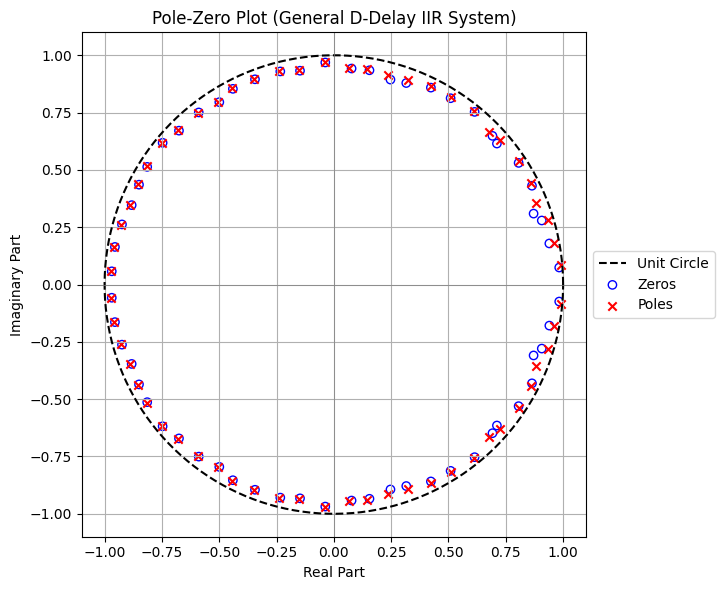

coeffs b: [-0.0061763  -0.00950059 -0.00946357 -0.00941922 -0.00950663 -0.00938483
 -0.00933684 -0.00950584 -0.00918346 -0.00954201 -0.00939358 -0.00938174
 -0.0093954  -0.00951953 -0.00955207 -0.00955501 -0.00929202 -0.00866018
 -0.0094275  -0.00937675 -0.00946613 -0.00942522 -0.00927308 -0.00951019
 -0.00856829 -0.00942048 -0.00947562 -0.00952066 -0.00954529 -0.00948314
 -0.00947348 -0.00891811 -0.00944751 -0.00921237 -0.00947927 -0.0095084
 -0.00936816 -0.00951533 -0.0094147  -0.00946989 -0.0094078  -0.00950148
 -0.00940004 -0.00950346 -0.00944037 -0.00953196 -0.00909711 -0.00934702
 -0.00936161 -0.00948871 -0.00954062 -0.00948427 -0.00943329 -0.00920589
 -0.00938276 -0.00945248 -0.00913111 -0.00938427 -0.00943695 -0.00952544
 -0.00667642]
coeffs a: [1.         0.03148599 0.04260859 0.06657469 0.0337292  0.09848429
 0.09587566 0.06432612 0.00917877 0.04686527 0.08303881 0.01904316
 0.09061567 0.02585063 0.03859214 0.04402468 0.01257113 0.0050612
 0.09384711 0.01380544 0.07030179 0.0

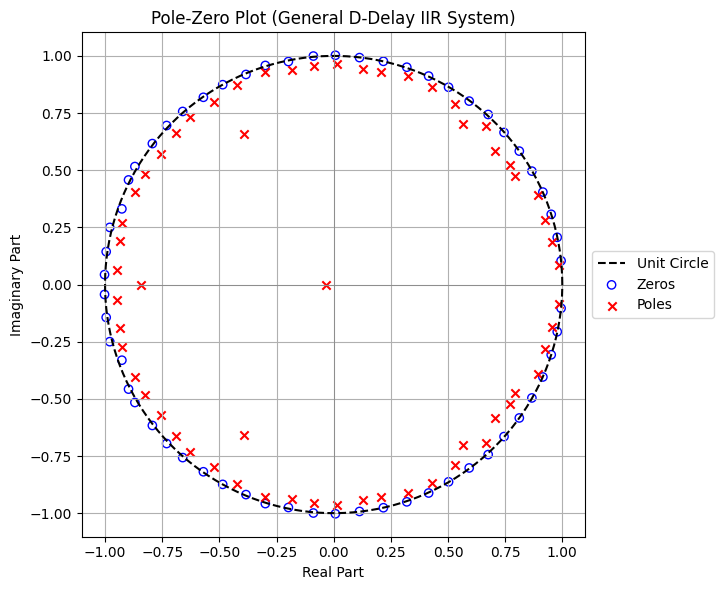

In [21]:
# for j in range(bs):
for ch in range(channels):
    # Plot for first batch and first channel
    b_example = b[ch,:]
    a_example = a[ch,:]
    print(f"coeffs b: {b_example}\ncoeffs a: {a_example}")
    plot_pole_zero(b_example, a_example)


coeffs b: [-3.5774317e-02  1.6992227e-03  1.5856319e-03  1.2325892e-03
  9.1113383e-04 -5.2176020e-04  3.9710733e-04  1.4216991e-03
  1.8535963e-03 -1.0152168e-03  1.7343498e-03 -4.0015019e-04
 -5.8152061e-04  1.0885465e-03  8.1047835e-04  1.5054466e-03
  1.6578775e-03 -3.5581784e-04  1.4931331e-03 -5.5929949e-04
  1.5512914e-03  1.1522358e-03  1.6837162e-03  1.6166808e-03
 -7.6077040e-04  7.0115668e-04  8.0280786e-04  1.7765210e-03
 -9.0339151e-04  1.5594756e-03  1.8196249e-03  1.6380895e-03
  1.5306449e-03  1.2287190e-03  8.3424884e-04 -9.9226017e-04
  1.8727970e-03  1.6003252e-03  1.8957916e-03  1.3300793e-03
  6.8286411e-04  1.3748432e-03  1.5148069e-03 -2.2889976e-04
  7.7663921e-05 -4.2148633e-05  5.2906922e-04  1.2330995e-03
  3.0109333e-04 -1.5474646e-04  1.6212802e-03  1.6146707e-03
  4.8392662e-04 -6.9768401e-05  1.2163490e-03  9.7547646e-04
  1.2040220e-03  6.3994573e-04  2.8201309e-04  1.3760291e-07
  1.3001940e-03]
coeffs a: [1.         0.02336409 0.02744638 0.0381056  0.0

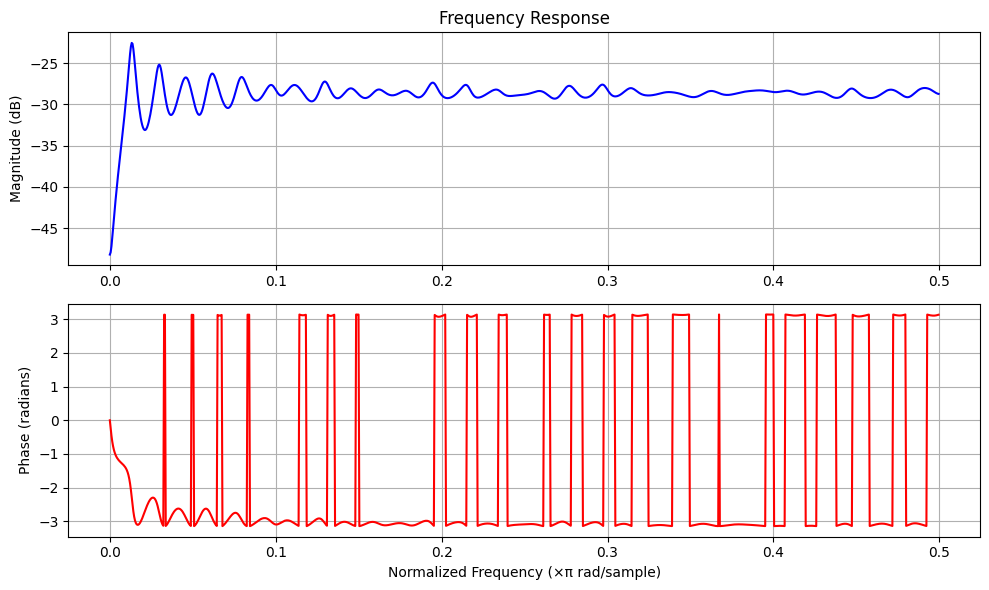

coeffs b: [0.03002924 0.00923231 0.00837193 0.00973512 0.00969918 0.00968094
 0.00862116 0.00748941 0.00958496 0.00976095 0.00780273 0.00578249
 0.01008459 0.00981359 0.00603783 0.0098213  0.00651787 0.00984601
 0.00953208 0.00911839 0.00937392 0.00837858 0.00966011 0.00614732
 0.00848581 0.00963787 0.00985482 0.00981157 0.00921311 0.00888416
 0.00884588 0.0094561  0.00610254 0.00828646 0.00794993 0.00949926
 0.00894232 0.00832474 0.00910904 0.00837005 0.0081244  0.00869986
 0.00549542 0.00760512 0.00736462 0.0096194  0.00987508 0.0085482
 0.00060689 0.00930785 0.00981531 0.00823732 0.00865734 0.00817039
 0.00478239 0.00727626 0.0079634  0.00940103 0.01001415 0.00928445
 0.00933683]
coeffs a: [1.0000000e+00 6.4071991e-02 3.5418738e-02 8.1901073e-02 8.1826024e-02
 8.2030788e-02 4.4576477e-02 1.9040752e-02 7.7697180e-02 8.5562646e-02
 2.3109591e-02 6.4228773e-03 9.5957898e-02 8.6055651e-02 7.6011657e-03
 8.5821711e-02 1.0047734e-02 8.7826826e-02 7.5043403e-02 6.0513962e-02
 6.8841159e-02

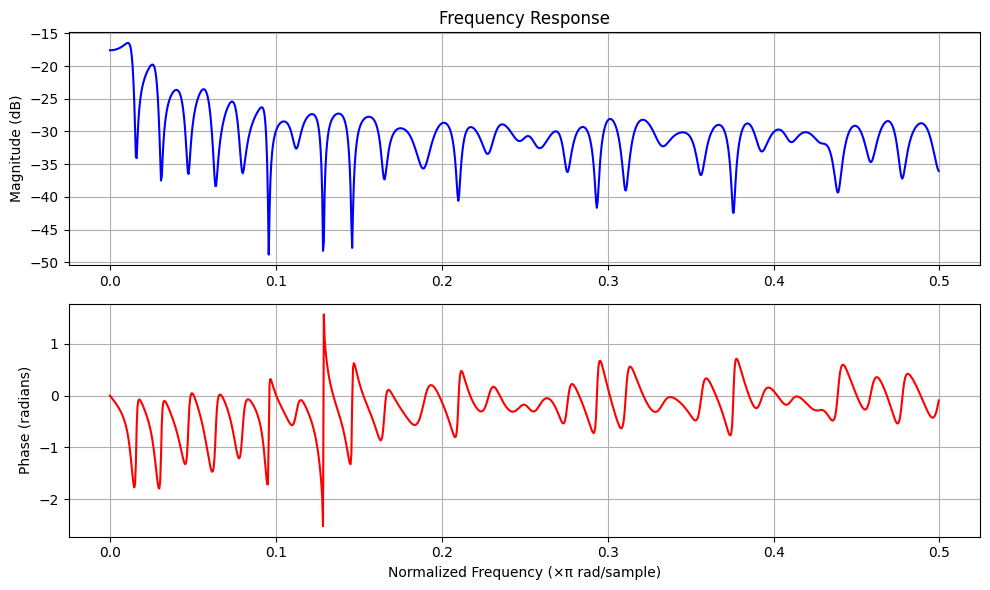

coeffs b: [-0.02621378 -0.00980865 -0.01003724 -0.00352455 -0.00923118 -0.00980494
 -0.01076492 -0.01065683 -0.00936588 -0.00936826 -0.0089134  -0.00951946
 -0.00979218 -0.00897151 -0.00814394 -0.0083782  -0.01067942 -0.01068221
 -0.00980145 -0.00959972 -0.0076599  -0.01093178 -0.00940058 -0.01021733
 -0.00989705 -0.01003847 -0.00966311 -0.01061385 -0.00208424 -0.01079649
 -0.00978077 -0.01033568 -0.0097593  -0.00677282 -0.0098952  -0.01072682
 -0.01097499 -0.0101142  -0.00993012 -0.01005505 -0.00919383 -0.0098457
 -0.01078414 -0.01021378 -0.00772477 -0.0038697  -0.01007603 -0.009606
 -0.0101527  -0.0103886  -0.0073317  -0.01089012 -0.0097229  -0.01015437
 -0.00383852 -0.00856118 -0.01028838 -0.00985818 -0.01028865 -0.01001522
 -0.01005345]
coeffs a: [1.0000000e+00 4.0755462e-02 5.1287580e-02 7.8358653e-04 2.1140873e-02
 4.4159867e-02 8.7057590e-02 8.6369097e-02 2.6629901e-02 2.7430667e-02
 1.6050994e-02 3.2039370e-02 4.3079305e-02 1.7351424e-02 7.7057839e-03
 9.5625399e-03 8.6121872e-

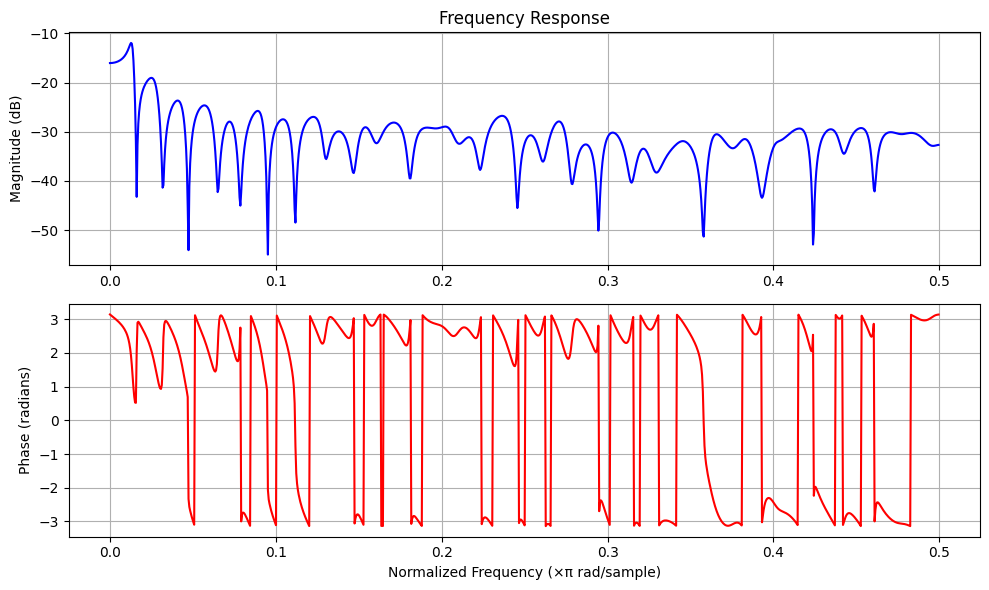

coeffs b: [-0.01966461 -0.00802457 -0.00493452 -0.00844422 -0.00745484 -0.00850153
 -0.00815751 -0.00501409 -0.00820338 -0.0077686  -0.00771541 -0.0066169
 -0.00455819 -0.00813896 -0.00809593 -0.00853477 -0.00820933 -0.00836235
 -0.00607656 -0.00742094 -0.00597079 -0.00735576 -0.00764588 -0.00850426
 -0.00726238 -0.00835375 -0.00747703 -0.00767244 -0.00835847 -0.00795467
 -0.00848711 -0.00746272 -0.0075445  -0.00755442 -0.00589566 -0.00746995
 -0.00762294 -0.00834822 -0.00779825 -0.00786536 -0.00460845 -0.00774072
 -0.00790131 -0.00705842 -0.00645302 -0.00523903 -0.00833511 -0.00691848
 -0.00790506 -0.00756466 -0.00795544 -0.00603045 -0.00297222 -0.00820782
 -0.00727819 -0.00819768 -0.00773253 -0.00748427 -0.0074832  -0.00798244
 -0.00741623]
coeffs a: [1.         0.06550985 0.00479937 0.0946631  0.03429356 0.09347724
 0.07533758 0.00507588 0.07825545 0.0506704  0.04922092 0.01514063
 0.00399563 0.07400196 0.06767926 0.09532042 0.07577632 0.08935203
 0.00973091 0.03376338 0.00940141 0.

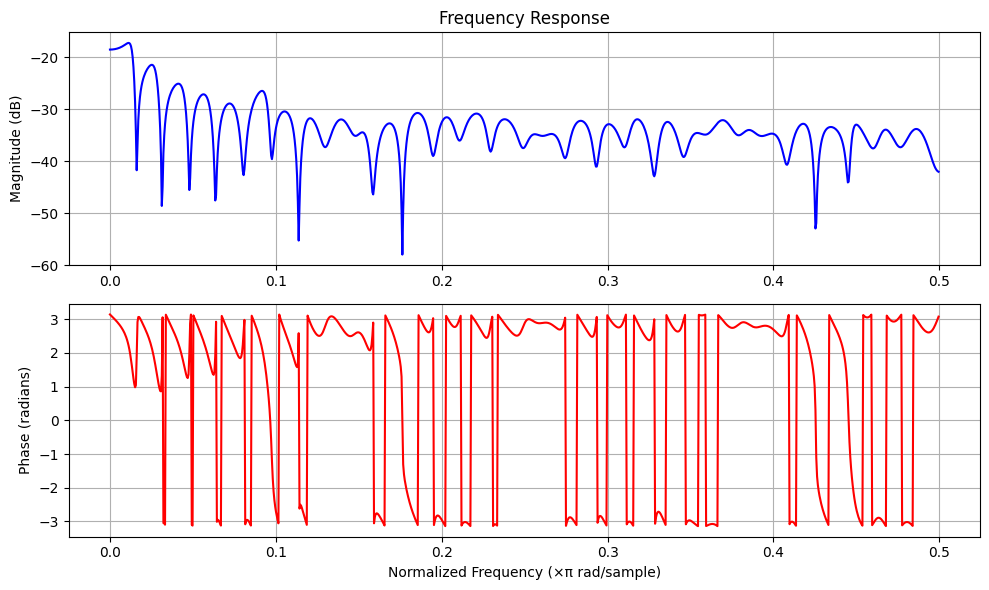

coeffs b: [ 0.00158041 -0.00287692 -0.00293823 -0.00296739 -0.00143552 -0.00288314
 -0.002914   -0.00296007 -0.00297446 -0.00286245 -0.00295869 -0.00288673
 -0.00288146 -0.00272496 -0.00274561 -0.0028644  -0.00291575 -0.00294449
 -0.00292508 -0.00284893 -0.00285121 -0.00297525 -0.00293681 -0.00279827
 -0.00292475 -0.00206765 -0.00296658 -0.00289463 -0.00294397 -0.00280781
 -0.00290265 -0.0028463  -0.00294925 -0.00293313 -0.00251811 -0.00297169
 -0.00281678 -0.00298165 -0.00296824 -0.00295259 -0.00294757 -0.00292222
 -0.00289151 -0.00276928 -0.0029285  -0.00281621 -0.00297675 -0.00210639
 -0.00283919 -0.00286425 -0.00298422 -0.00293256 -0.00296486 -0.00287807
 -0.00297721 -0.00296077 -0.00292824 -0.00289288 -0.0028763  -0.00290245
 -0.00290876]
coeffs a: [1.         0.08676535 0.07089912 0.05981419 0.0030606  0.09488881
 0.07347538 0.06599069 0.05812149 0.08988234 0.03687987 0.08241206
 0.09395847 0.01791962 0.01891505 0.09945367 0.08131857 0.0426976
 0.07526898 0.09532186 0.09928282 0.

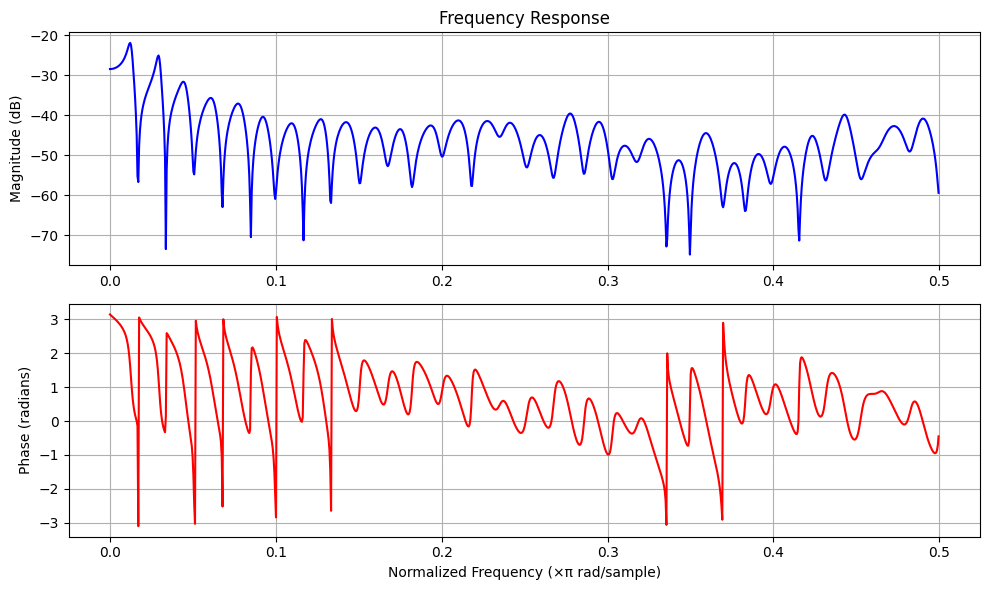

coeffs b: [ 0.0416035  -0.00619846 -0.0058397  -0.00677795 -0.00494645 -0.00695733
 -0.00506436 -0.00543168 -0.00590861 -0.00382122 -0.00685198 -0.00698498
 -0.00435861 -0.00613914 -0.00668831 -0.00682652 -0.00641947 -0.0067731
 -0.00642886 -0.00549533 -0.00500472 -0.0060013  -0.00684999 -0.00597622
 -0.0045133  -0.00416732 -0.00543085 -0.00398148 -0.00680794 -0.00708296
 -0.00661372 -0.00572018 -0.00560828 -0.00539462 -0.00626515 -0.00531478
 -0.00681004 -0.00467995 -0.00692425 -0.00474444 -0.00361914 -0.00557184
 -0.00691859 -0.00711531 -0.00492402 -0.00649766 -0.00584237 -0.00492227
 -0.00453833 -0.00355562 -0.00613782 -0.00713848 -0.0063627  -0.0055375
 -0.00462465 -0.00480867 -0.0058994  -0.00714534 -0.00347752 -0.00517042
 -0.00534665]
coeffs a: [1.         0.0429193  0.00307132 0.03035893 0.06908851 0.02351257
 0.0671037  0.05859257 0.04819851 0.09346779 0.02631698 0.02212888
 0.0819132  0.04322689 0.03209066 0.02700045 0.03836821 0.02848674
 0.03857354 0.05901879 0.06977862 0.0

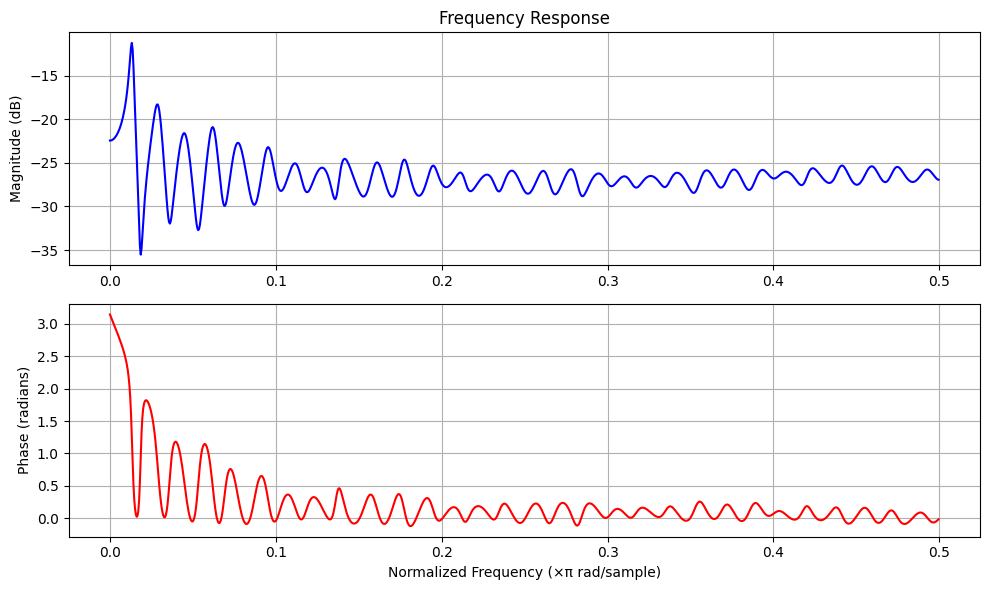

coeffs b: [-0.01363024 -0.00565644 -0.00437176 -0.00464845 -0.00391399 -0.0057941
 -0.00437183 -0.0053722  -0.00226412 -0.00516668 -0.00525908 -0.00335884
 -0.00534747 -0.0056208  -0.0053023  -0.00043358 -0.00536001 -0.00587187
 -0.0057514  -0.00582387 -0.00526128 -0.00469037 -0.00301589 -0.00538748
 -0.00338489 -0.0041031  -0.00478149 -0.00206    -0.00526077 -0.00524985
 -0.0046688  -0.00551558 -0.00573404 -0.00032761 -0.00542471 -0.00510478
 -0.0054663  -0.00534578 -0.00549287 -0.00524299 -0.00155499 -0.00566252
 -0.00495563 -0.00416708 -0.00559205 -0.00579608 -0.00409349 -0.00461629
 -0.00571814 -0.00533341 -0.00426589 -0.00580066 -0.00532963 -0.00580846
 -0.0057316  -0.00523863 -0.00567527 -0.00546081 -0.00511271 -0.00496888
 -0.00573981]
coeffs a: [1.00000000e+00 8.20023343e-02 1.57118198e-02 2.21185330e-02
 9.61929560e-03 9.83811617e-02 1.60451420e-02 5.60241453e-02
 2.63754139e-03 4.18462418e-02 5.21894097e-02 5.97139588e-03
 5.44669405e-02 7.71925449e-02 5.08965850e-02 3.100514

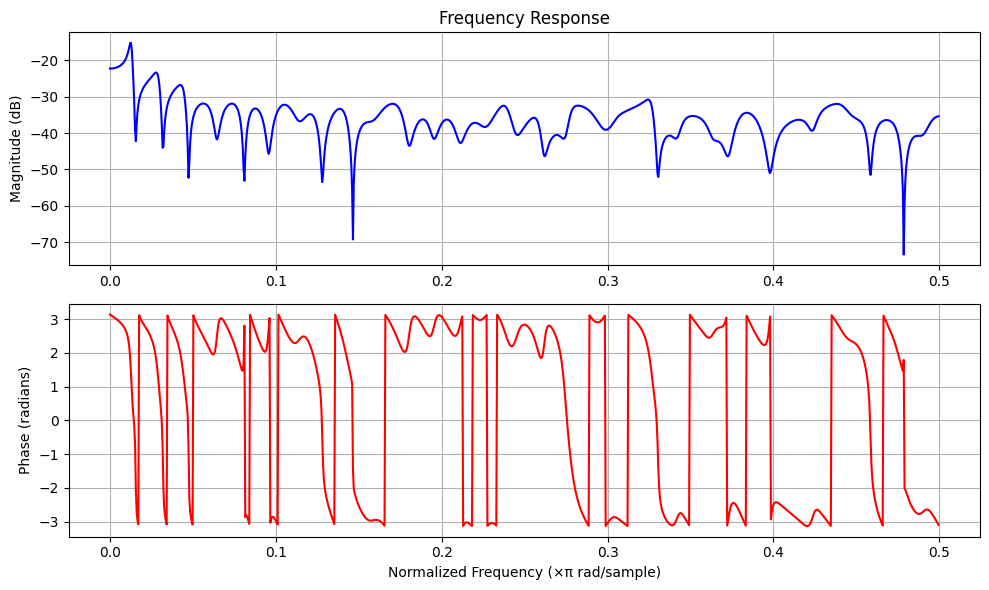

coeffs b: [0.03696042 0.00975364 0.00923428 0.01060986 0.01110052 0.01204485
 0.01114406 0.00907455 0.00981355 0.00847762 0.01074223 0.01098598
 0.00990926 0.01011236 0.00940356 0.00450705 0.01184659 0.01217472
 0.01139798 0.00356232 0.01232618 0.01196376 0.01121907 0.01044455
 0.00947515 0.0117191  0.00975413 0.01099047 0.01189128 0.0120902
 0.01086808 0.00887657 0.01005991 0.01054556 0.01021629 0.01004332
 0.01071475 0.01163129 0.01163549 0.01130512 0.01210724 0.00967517
 0.0094918  0.01196548 0.01201637 0.0111525  0.01183794 0.01013506
 0.00713277 0.01018223 0.0113413  0.01064064 0.01212775 0.00986398
 0.01136484 0.0104708  0.00886055 0.01000649 0.01074566 0.00922015
 0.01147639]
coeffs a: [1.0000000e+00 2.0774221e-02 1.3141406e-02 4.3101944e-02 6.0395766e-02
 9.2652991e-02 6.3185252e-02 1.1230267e-02 2.3209108e-02 6.6206097e-03
 4.6593368e-02 5.7321131e-02 2.4070919e-02 3.0619955e-02 1.5256166e-02
 9.4918016e-04 8.7518387e-02 9.5055178e-02 6.9960773e-02 6.2750577e-04
 9.9836230e-02

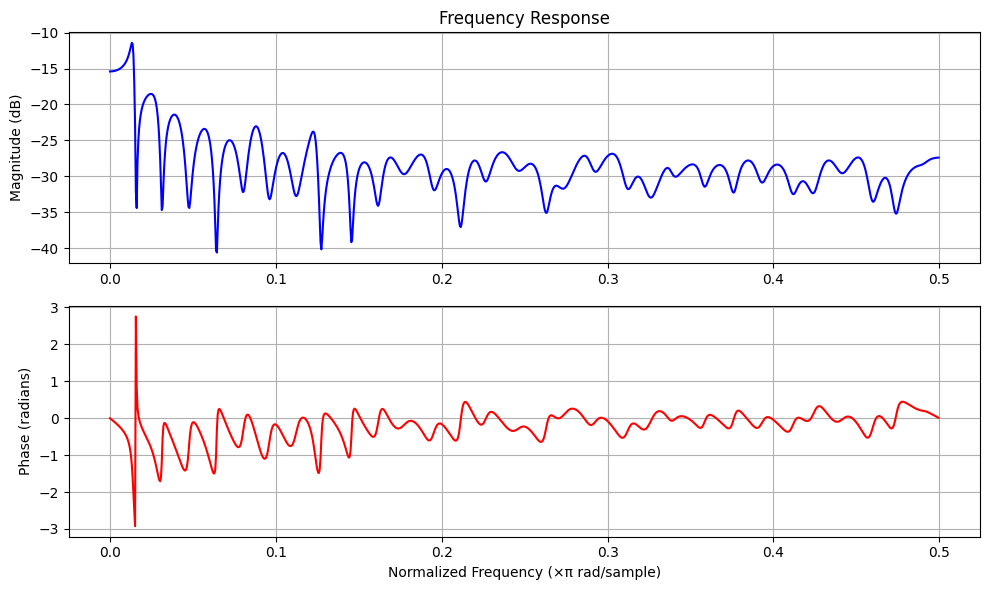

coeffs b: [-0.01046593 -0.00896626 -0.00901191 -0.00917635 -0.00870567 -0.00882195
 -0.00871195 -0.00873602 -0.00852109 -0.00899045 -0.00836194 -0.00769757
 -0.009078   -0.00645455 -0.00906937 -0.00916837 -0.00799515 -0.00883388
 -0.0082989  -0.00906819 -0.00876994 -0.00910283 -0.00880913 -0.00877786
 -0.00917499 -0.00869223 -0.00890532 -0.00885234 -0.00899781 -0.00910237
 -0.00915246 -0.0082336  -0.00902825 -0.00908124 -0.00786275 -0.0091127
 -0.00915452 -0.00632619 -0.00859097 -0.00795371 -0.00576793 -0.00310783
 -0.0091854  -0.00894151 -0.00919281 -0.00913997 -0.00880733 -0.00858419
 -0.00893304 -0.00891623 -0.00909762 -0.00915467 -0.00851901 -0.00873884
 -0.00902384 -0.00860395 -0.00876002 -0.00872689 -0.008679   -0.00895438
 -0.00808279]
coeffs a: [1.         0.05600346 0.06417622 0.09658022 0.03382286 0.038213
 0.0335641  0.03263041 0.02219788 0.06725375 0.02055912 0.00994519
 0.0894989  0.00464406 0.08881076 0.09746265 0.01314007 0.04035083
 0.01895549 0.08668496 0.0356195  0.09

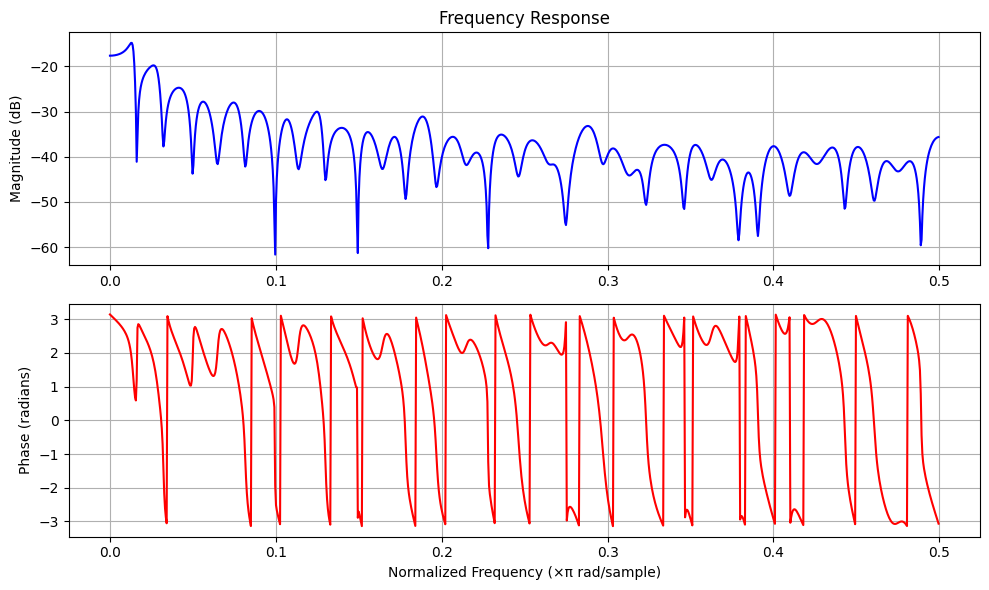

coeffs b: [-0.00288169 -0.00734651 -0.00614186 -0.00737536 -0.00734388 -0.00732622
 -0.00741464 -0.00729907 -0.00723267 -0.00727614 -0.00736335 -0.00731926
 -0.00733714 -0.0073739  -0.00697336 -0.00742062 -0.0069557  -0.00741739
 -0.00707913 -0.00738445 -0.00555044 -0.00738224 -0.00737246 -0.00734848
 -0.00746663 -0.00741954 -0.00728964 -0.00688103 -0.00739535 -0.00746789
 -0.00741288 -0.00736916 -0.00737586 -0.00736498 -0.00738341 -0.00741821
 -0.00733925 -0.00747069 -0.00737254 -0.0074651  -0.00747215 -0.00724285
 -0.00741775 -0.00737481 -0.00741637 -0.00742661 -0.00643824 -0.0072395
 -0.00737272 -0.00714976 -0.00730751 -0.00738071 -0.00566306 -0.0073792
 -0.00741924 -0.00734435 -0.00735778 -0.00742907 -0.00734732 -0.00738681
 -0.00747242]
coeffs a: [1.         0.03368847 0.00687611 0.04012007 0.028061   0.09575403
 0.04723924 0.09425193 0.02267048 0.0237604  0.07063488 0.09155922
 0.09251823 0.09302162 0.01500322 0.0871798  0.01427619 0.07715044
 0.0175161  0.06904642 0.00475332 0.0

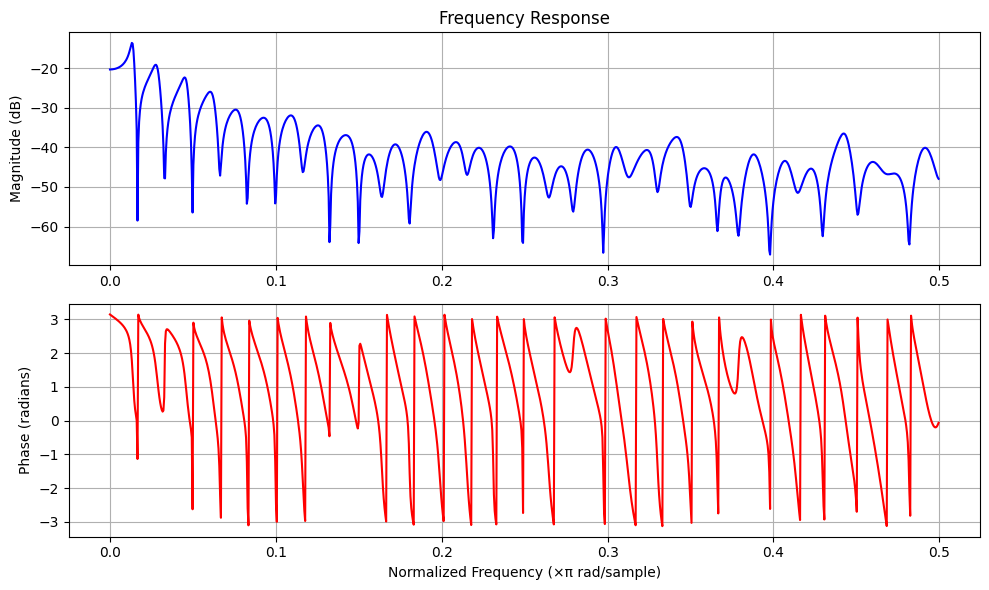

coeffs b: [-1.67850461e-02  3.23457643e-04  1.49707426e-04 -9.46621876e-04
  1.16303330e-04  1.23967737e-04 -8.48955533e-04  1.60889496e-04
 -6.45174994e-04  2.38785142e-04 -9.94671718e-05 -1.05426367e-03
  8.20216956e-05  1.85225566e-04 -9.15382348e-04  2.29292025e-04
 -6.66498090e-05 -5.19072637e-05  2.70270160e-04 -6.79298537e-05
 -7.58350128e-04  2.62007001e-04 -3.06367932e-04  6.66120322e-05
  3.01918742e-04 -5.55212901e-04 -5.44804498e-05 -1.68921542e-04
  2.83290865e-05 -4.12310124e-04 -1.03930919e-03  9.58204619e-05
 -9.30587878e-04 -9.24991735e-04 -4.53260727e-05 -1.53755536e-04
 -1.19971926e-04 -9.64495412e-04 -9.49489477e-04 -1.27587584e-04
 -6.68216380e-04 -4.37941810e-04  2.50602781e-04  1.99655013e-04
 -3.03704699e-04 -5.48031181e-04 -7.07569474e-04 -1.01065729e-03
 -9.50666494e-04 -2.84439593e-04 -6.78307319e-04  2.09269841e-04
 -7.11776258e-04 -4.10370820e-04 -4.15353512e-04  1.52699678e-04
 -1.04573322e-04 -7.98805850e-05 -4.35457274e-04  2.12616636e-04
 -1.04796246e-0

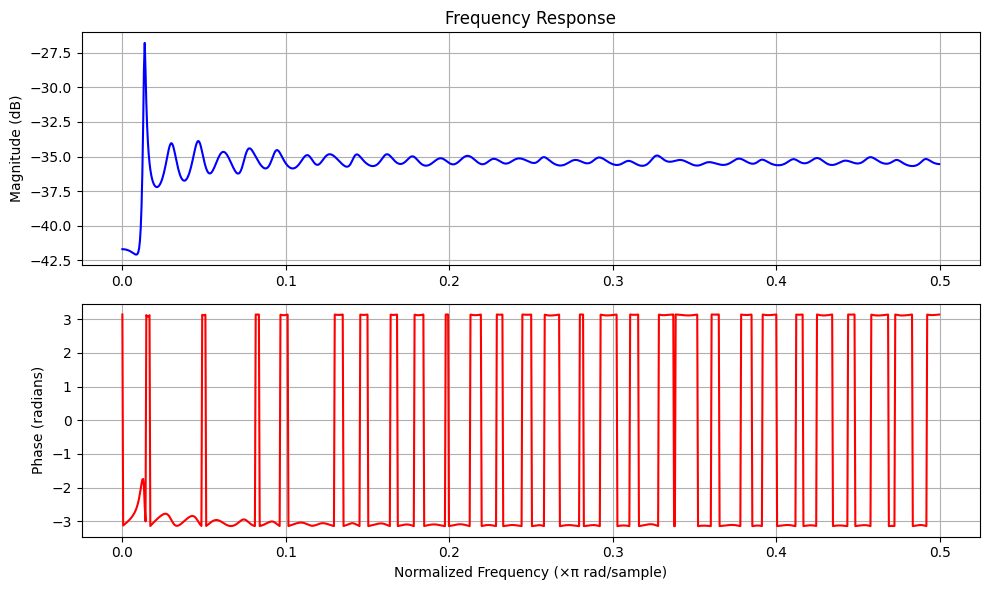

coeffs b: [-0.0061763  -0.00950059 -0.00946357 -0.00941922 -0.00950663 -0.00938483
 -0.00933684 -0.00950584 -0.00918346 -0.00954201 -0.00939358 -0.00938174
 -0.0093954  -0.00951953 -0.00955207 -0.00955501 -0.00929202 -0.00866018
 -0.0094275  -0.00937675 -0.00946613 -0.00942522 -0.00927308 -0.00951019
 -0.00856829 -0.00942048 -0.00947562 -0.00952066 -0.00954529 -0.00948314
 -0.00947348 -0.00891811 -0.00944751 -0.00921237 -0.00947927 -0.0095084
 -0.00936816 -0.00951533 -0.0094147  -0.00946989 -0.0094078  -0.00950148
 -0.00940004 -0.00950346 -0.00944037 -0.00953196 -0.00909711 -0.00934702
 -0.00936161 -0.00948871 -0.00954062 -0.00948427 -0.00943329 -0.00920589
 -0.00938276 -0.00945248 -0.00913111 -0.00938427 -0.00943695 -0.00952544
 -0.00667642]
coeffs a: [1.         0.03148599 0.04260859 0.06657469 0.0337292  0.09848429
 0.09587566 0.06432612 0.00917877 0.04686527 0.08303881 0.01904316
 0.09061567 0.02585063 0.03859214 0.04402468 0.01257113 0.0050612
 0.09384711 0.01380544 0.07030179 0.0

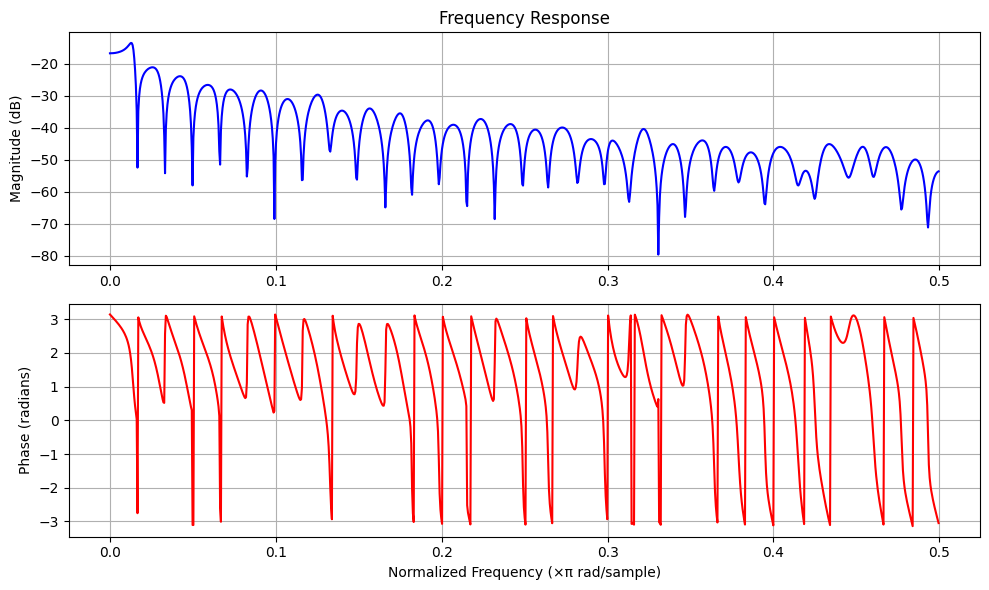

In [22]:
# for j in range(bs):
for ch in range(channels):
    # Plot for first batch and first channel
    b_example = b[ch,:]
    a_example = a[ch,:]
    print(f"coeffs b: {b_example}\ncoeffs a: {a_example}")
    plot_frequency_response(b_example, a_example)

In [23]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
# plot_frequency_response(b_opt, a_full)

# Rough

In [ ]:
# import tensorflow as tf
# from tensorflow.keras.constraints import NonNeg

# class CircularShiftND(tf.keras.layers.Layer):
#     def __init__(self, D, **kwargs):
#         super().__init__(**kwargs)
#         self.Delays = D

#     def build(self, input_shape):
#         self.N = input_shape[1]
#         # Compute index shifts (D+1, N): rows of [n, n-1, ..., n-D] mod N
#         n = tf.range(self.N)
#         shifts = tf.range(self.Delays + 1)[:, None]  # (D+1, 1)
#         self.indices = tf.math.mod(n[None, :] - shifts, self.N)  # (D+1, N)

#         """
#         N: input x[n] signal length
#         channels 
#         """
#         _, self.N, self.channels = input_shape
        
#         ## all a coefficient 
#         self.b = self.add_weight(
#             shape=(self.channels, self.Delays + 1), 
#             initializer="random_normal", 
#             trainable=True, 
#             name="b_coeffs",
#             constraint=NonNeg()
#             )

#         # all b coefficient 
#         self.a = self.add_weight(
#             shape=(self.channels, self.Delays), 
#             initializer="random_normal", 
#             trainable=True, 
#             name="a_coeffs",
#             constraint=NonNeg()
#             )
#         a0s = tf.ones((self.channels, 1))
#         self.a = tf.concat([a0s, self.a], axis=-1)

#         # output initialize
#         self.y = self.add_weight(
#             shape=input_shape, 
#             initializer="zeros", 
#             trainable=True, 
#             name="y_init")



#     def call(self, x):
#         residual = self.__computeBXminusAY(x)
#         return residual

#     def __computeBXminusAY(self,x):
#         Xshifted = self.__circularshift(x)
#         Yshifted = self.__circularshift(self.y)
#         BX = tf.einsum('abcd,cd->abcd', Xshifted, self.b)
#         AY = tf.einsum('abcd,cd->abcd', Yshifted, self.a)
#         self.Xshifted = Xshifted
#         self.Yshifted = Yshifted
#         self.BX = BX
#         self.AY = AY
#         return BX-AY
        
#     def __circularshift(self,x):
#         # x shape: (batch, N, channels)
#         batch, N, channels = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2]

#         # Transpose to (N, batch, channels)
#         xT = tf.transpose(x, perm=[1, 0, 2])  # (N, B, C)

#         # Gather using precomputed indices: (D+1, N, B, C)
#         shifted = tf.gather(xT, self.indices, axis=0)

#         # Transpose to (B, N, C, D+1)
#         shifted_final = tf.transpose(shifted, perm=[2, 1, 3, 0])
#         return shifted_final

# # x = tf.constant([[[1], [2], [3], [4]]], dtype=tf.float32)  # shape (1, 4, 1)

# # Dummy data
# batch_size = 10
# N = 5
# channels = 3
# x = tf.random.normal((batch_size, N, channels))
# # y_train = x_train+0.01
# # y_train = tf.random.normal((batch_size, N, channels))



# layer = CircularShiftND(D=N-1)
# out = layer(x)
# print(out.numpy())


In [ ]:
# x.shape, x[0,:,0], out.shape, out[0,:,0,0], 

In [ ]:
# for i in range(layer.Xshifted.shape[-1]):
    # print(layer.Xshifted[0,:,0,i].numpy())

In [ ]:
# for i in range(layer.Yshifted.shape[-1]):
#     print(layer.Yshifted[0,:,0,i].numpy())

In [ ]:
# for i in range(layer.BX.shape[-1]):
#     print(layer.BX[0,:,0,i].numpy())

In [ ]:
# for i in range(layer.AY.shape[-1]):
#     print(layer.AY[0,:,0,i].numpy())

In [ ]:
# x.shape, layer.y.shape

In [ ]:
# layer.Xshifted.shape, layer.Yshifted.shape

In [ ]:
# layer.b.shape, layer.a.shape, layer.b

In [ ]:
# layer.BX.shape, layer.AY.shape, 